# Dataset paper pinn

In [1]:
# Download the dataset
!wget https://raw.githubusercontent.com/maziarraissi/PINNs/master/main/Data/cylinder_nektar_wake.mat -O ../data/cylinder/cylinder_nektar_wake.mat


--2025-12-22 15:56:40--  https://raw.githubusercontent.com/maziarraissi/PINNs/master/main/Data/cylinder_nektar_wake.mat
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.110.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 24081984 (23M) [application/octet-stream]
Guardando como: ‘../data/cylinder/cylinder_nektar_wake.mat’

../data/cylinder/cy 100%[===================>]  22,97M  47,1MB/s    en 0,5s    

2025-12-22 15:56:42 (47,1 MB/s) - ‘../data/cylinder/cylinder_nektar_wake.mat’ guardado [24081984/24081984]



In [2]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt


data = loadmat("../data/cylinder/cylinder_nektar_wake.mat")

In [3]:
data.keys(), data["X_star"].shape, data['p_star'].shape

(dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star']),
 (5000, 2),
 (5000, 200))

In [4]:
np.unique(data["X_star"][:, 1]).shape

(50,)

(200, 50, 100)


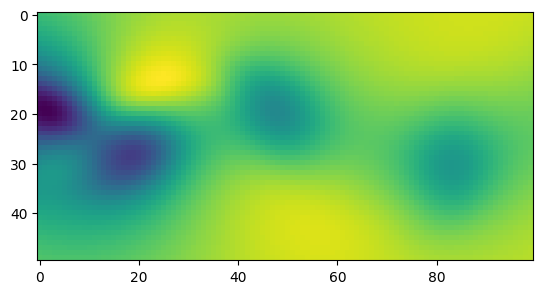

In [5]:
presiones = data['p_star'].reshape(50, 100, -1).transpose(2, 0, 1)
print(presiones.shape)
plt.imshow(presiones[0])
# plt.imshow(data['p_star'][:, 0].reshape(50, 100))

(64, 128)


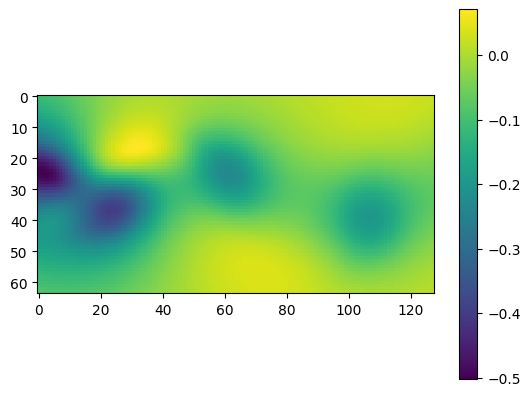

In [6]:
import numpy as np
from scipy.ndimage import zoom


# Calculate zoom factors
zoom_factors = (64/50, 128/100)  # (1.28, 1.28)

# Upsample using bilinear interpolation
upsampled = zoom(presiones[0], zoom_factors, order=1)
print(upsampled.shape)  # Should be (64, 128)
im = plt.imshow(upsampled)
plt.colorbar(im)

KeyboardInterrupt: 

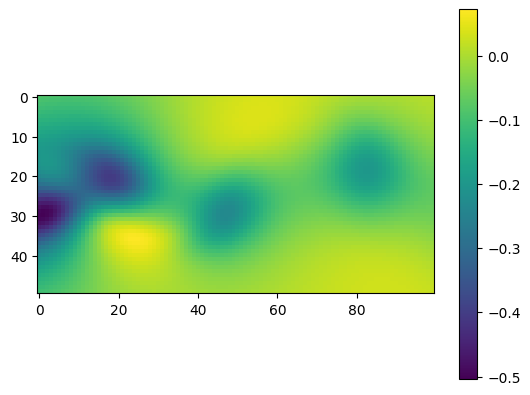

In [7]:
import matplotlib.animation as animation

fig, ax = plt.subplots()
im = ax.imshow(presiones[0], animated=True)
plt.colorbar(im)

def update(frame):
    im.set_array(presiones[frame])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=presiones.shape[0], blit=True)
ani.save("presiones.gif", writer="pillow", fps=5)
plt.close(fig)

# Nvidia cylinder dataset

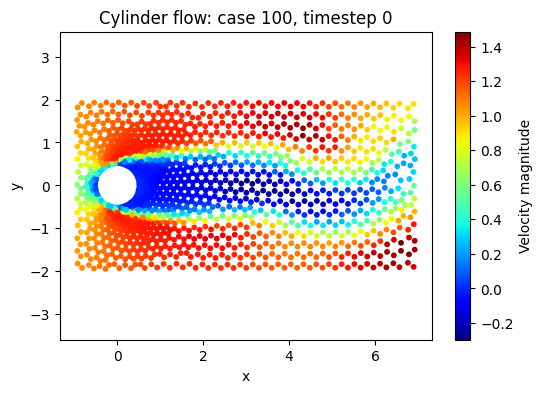

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = np.load("dataset/rawData.npy", allow_pickle=True)#.item()

x = data['x']         # shape (time, case, nodes, vars)
coords = np.loadtxt("dataset/meshPosition_all.txt")  # shape (nodes, 2), columns [x,y]

# Choose one case and one time step
t_idx = 0       # first timestep
case_idx = 100    # first simulation
snapshot = x[t_idx, case_idx]  # shape (nodes, 3)

u = snapshot[:,0]   # x-velocity
v = snapshot[:,1]   # y-velocity
p = snapshot[:,2]   # pressure

# Plot velocity magnitude
vel_mag = np.sqrt(u**2 + v**2)

plt.figure(figsize=(6,4))
sc = plt.scatter(coords[:,0], coords[:,1], c=u, cmap="jet", s=10)
plt.colorbar(sc, label="Velocity magnitude")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cylinder flow: case {}, timestep {}".format(case_idx, t_idx))
plt.axis("equal")
plt.show()


In [ ]:
import numpy as np
arr = np.load("dataset/rawData.npy", allow_pickle=True)

In [ ]:
arr.keys(), arr["x"].shape

(dict_keys(['x', 'edge_attr', 'edge_index', 'mass', 'para']),
 (101, 401, 1699, 3))

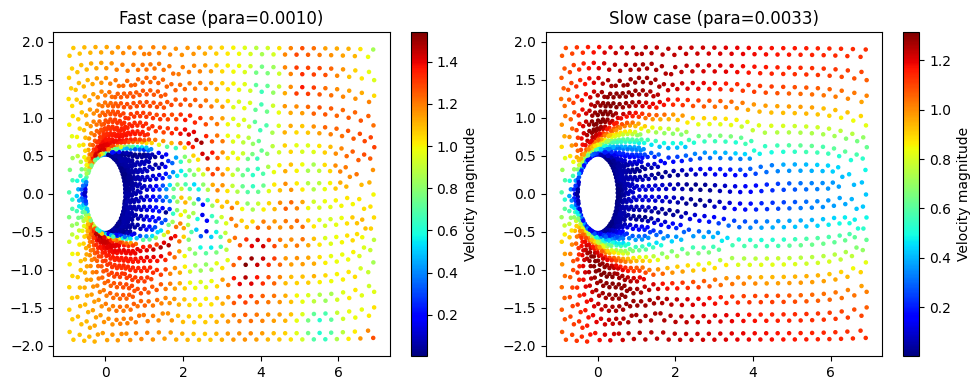

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("dataset/rawData.npy", allow_pickle=True)#.item()
coords = np.loadtxt("dataset/meshPosition_all.txt")
x = data['x']
para = data['para']

# Pick two cases: smallest vs largest parameter
case_fast = np.argmin(para)
case_slow = np.argmax(para)

# Take final timestep snapshot
t_idx = -1
snap_fast = x[t_idx, case_fast]
snap_slow = x[t_idx, case_slow]

u_fast, v_fast = snap_fast[:,0], snap_fast[:,1]
u_slow, v_slow = snap_slow[:,0], snap_slow[:,1]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(coords[:,0], coords[:,1], c=np.sqrt(u_fast**2+v_fast**2), s=5, cmap="jet")
plt.colorbar(label="Velocity magnitude")
plt.title(f"Fast case (para={para[case_fast]:.4f})")

plt.subplot(1,2,2)
plt.scatter(coords[:,0], coords[:,1], c=np.sqrt(u_slow**2+v_slow**2), s=5, cmap="jet")
plt.colorbar(label="Velocity magnitude")
plt.title(f"Slow case (para={para[case_slow]:.4f})")

plt.tight_layout()
plt.show()


# CFDBench dataset

In [ ]:
from huggingface_hub import snapshot_download

# Download the whole CFDBench repo
dataset_path = snapshot_download(repo_id="chen-yingfa/CFDBench", repo_type="dataset", local_dir="../data/datasetCFDBench")

print("Dataset downloaded to:", dataset_path)


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/807 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

bc.zip:   0%|          | 0.00/2.94G [00:00<?, ?B/s]

cavity.zip:   0%|          | 0.00/786M [00:00<?, ?B/s]

tube.zip:   0%|          | 0.00/213M [00:00<?, ?B/s]

geo.zip:   0%|          | 0.00/2.41G [00:00<?, ?B/s]

dam.zip:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

prop.zip:   0%|          | 0.00/6.67G [00:00<?, ?B/s]

Dataset downloaded to: /home/d.ramos/pyLowOrder/datasetCFDBench


In [ ]:
import numpy as np
import zipfile

# pick a case index
case_idx = "0000"

# open geo (geometry)
with zipfile.ZipFile("datasetCFDBench/cylinder/geo.zip") as z:
    # unzip the file
    z.extractall("datasetCFDBench/cylinder/geo")

# open bc (boundary conditions)
with zipfile.ZipFile("datasetCFDBench/cylinder/bc.zip") as z:
    z.extractall("datasetCFDBench/cylinder/bc")


# open prop (properties)
with zipfile.ZipFile("datasetCFDBench/cylinder/prop.zip") as z:
    z.extractall("datasetCFDBench/cylinder/prop")



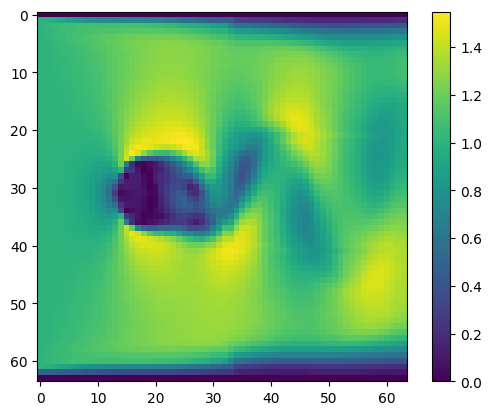

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

caso_ejemplo = "datasetCFDBench/cylinder/prop/case0060/u.npy"
u_ejemplo = np.load(caso_ejemplo)
im = plt.imshow(u_ejemplo[-1])
plt.colorbar(im)

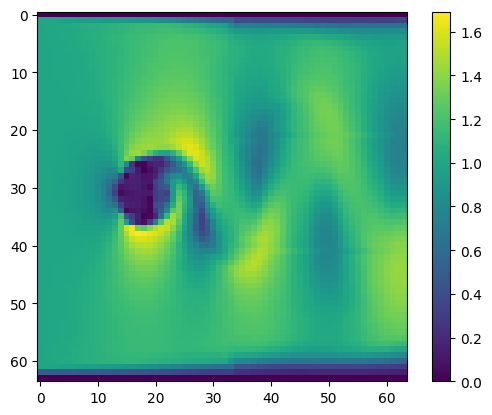

In [ ]:
caso_ejemplo = "datasetCFDBench/cylinder/prop/case0070/u.npy"
u_ejemplo = np.load(caso_ejemplo)
im = plt.imshow(u_ejemplo[-1])
plt.colorbar(im)

In [ ]:
import pandas as pd
from pathlib import Path

prop_dir = "datasetCFDBench/cylinder/prop/"

In [ ]:
df = None
for file in Path(prop_dir).glob("case*/case.json"):
    if df is None:
        print("Reading first file:", file)
        df = pd.read_json(file, typ='series').to_frame().T
        continue
    json_data = pd.read_json(file, typ='series').to_frame().T
    df = pd.concat([df, json_data], ignore_index=True)


Reading first file: datasetCFDBench/cylinder/prop/case0050/case.json


In [ ]:
df

,vel_in,density,viscosity,radius,x_min,x_max,y_min,y_max
0,1.0,1.0,0.0010,0.01,-0.06,0.16,-0.06,0.06
1,1.0,2.0,0.0010,0.01,-0.06,0.16,-0.06,0.06
2,1.0,3.0,0.0010,0.01,-0.06,0.16,-0.06,0.06
3,1.0,4.0,0.0010,0.01,-0.06,0.16,-0.06,0.06
4,1.0,5.0,0.0010,0.01,-0.06,0.16,-0.06,0.06
...,...,...,...,...,...,...,...,...
111,1.0,6.0,0.0005,0.01,-0.06,0.16,-0.06,0.06
112,1.0,7.0,0.0005,0.01,-0.06,0.16,-0.06,0.06
113,1.0,8.0,0.0005,0.01,-0.06,0.16,-0.06,0.06
114,1.0,9.0,0.0005,0.01,-0.06,0.16,-0.06,0.06


In [ ]:
df["density"].value_counts(), df["viscosity"].value_counts(), df["x_max"].value_counts()

(density
 1.0      4
 2.0      4
 3.0      4
 4.0      4
 5.0      4
 10.0     4
 6.0      3
 7.0      3
 8.0      3
 9.0      3
 50.0     3
 30.0     3
 40.0     3
 20.0     3
 11.0     2
 12.0     2
 13.0     2
 14.0     2
 15.0     2
 19.0     2
 18.0     2
 17.0     2
 16.0     2
 60.0     2
 70.0     2
 80.0     2
 90.0     2
 100.0    2
 0.7      2
 0.8      2
 0.5      2
 0.2      2
 0.3      2
 0.4      2
 0.9      2
 0.6      2
 0.1      2
 120.0    1
 110.0    1
 140.0    1
 150.0    1
 160.0    1
 130.0    1
 250.0    1
 240.0    1
 230.0    1
 220.0    1
 210.0    1
 200.0    1
 190.0    1
 180.0    1
 170.0    1
 400.0    1
 500.0    1
 300.0    1
 1.5      1
 2.5      1
 3.5      1
 4.5      1
 Name: count, dtype: int64,
 viscosity
 0.0050    28
 0.0100    28
 0.0010    23
 0.0005    19
 0.0001    18
 Name: count, dtype: int64,
 x_max
 0.16    116
 Name: count, dtype: int64)

# Dataset Laplace

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data_dir = "../data/laplace"

In [ ]:
simulations = np.load(f"{data_dir}/laplace_dataset_solutions.npy")  # shape (num_simulations, height, width)
parameters = np.load(f"{data_dir}/laplace_dataset_parameters.npy")  # shape (num_simulations, 2)

In [ ]:
# normalize the simulations to [0, 1]
sim_min = simulations.min(axis=(1,2), keepdims=True)
sim_max = simulations.max(axis=(1,2), keepdims=True)
simulations_norm = (simulations - sim_min) / (sim_max - sim_min)


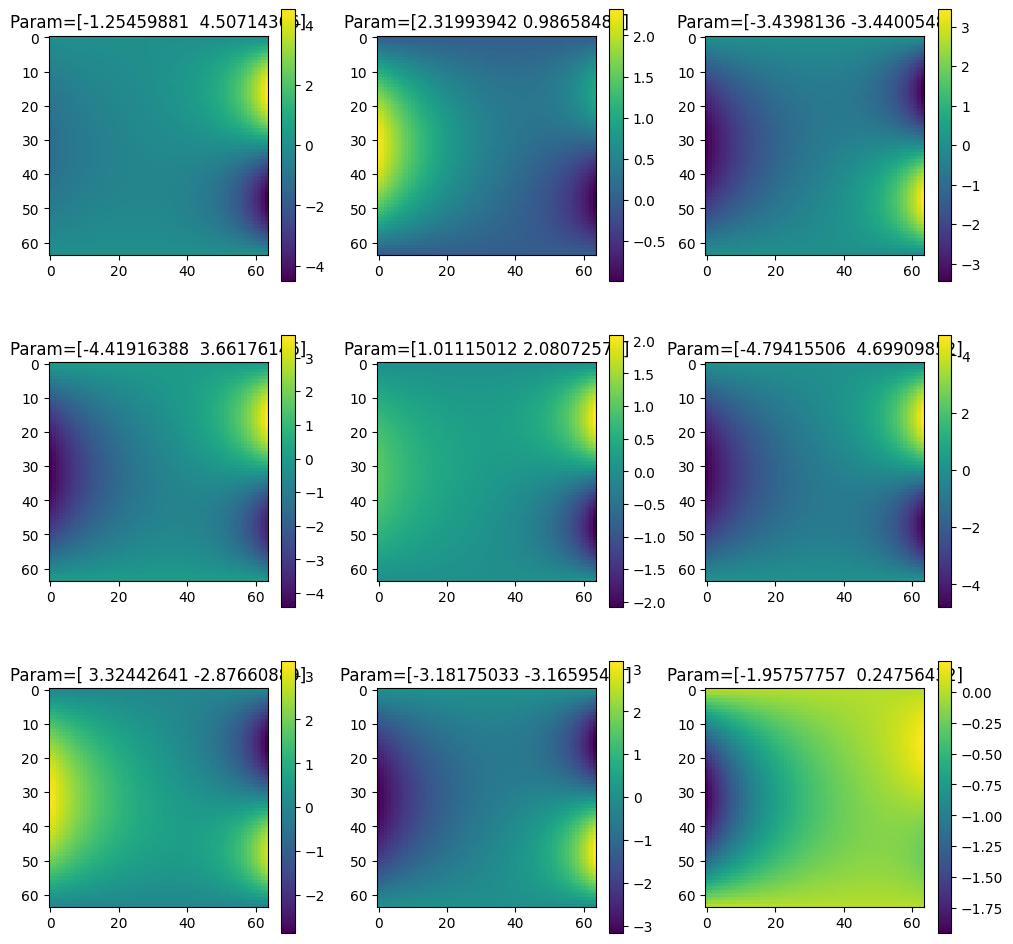

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12,12))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(simulations[i])#, vmin=np.min(simulations), vmax=np.max(simulations))#, cmap="jet")
    ax.set_title(f"Param={parameters[i]}")
    plt.colorbar(im, ax=ax)



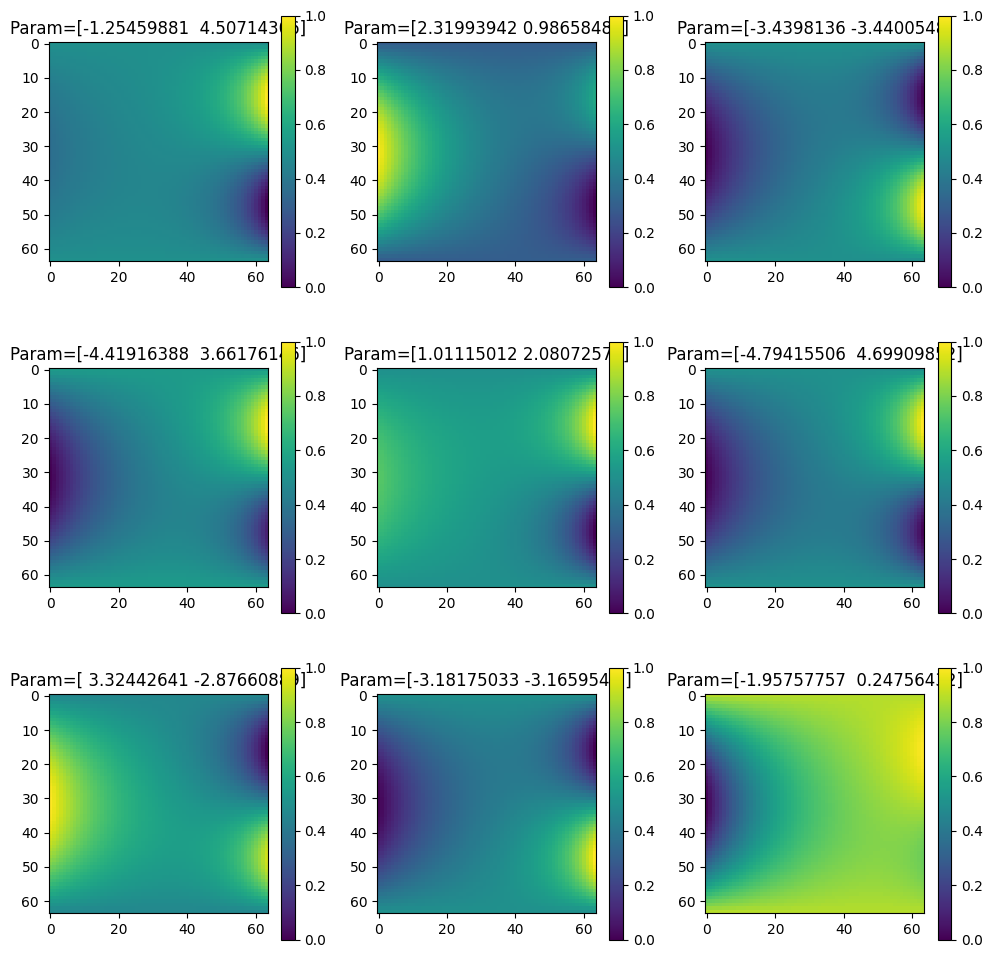

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12,12))

for i, ax in enumerate(axes.flat):
    im = ax.imshow(simulations_norm[i])
    ax.set_title(f"Param={parameters[i]}")
    plt.colorbar(im, ax=ax)

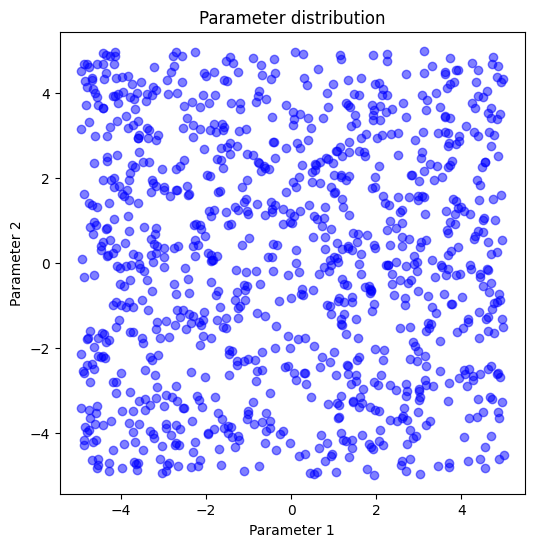

In [ ]:
# scatter plot of parameters

plt.figure(figsize=(6,6))
plt.scatter(parameters[:,0], parameters[:,1], c='blue', alpha=0.5)
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Parameter distribution")
plt.axis("equal")
plt.show()

In [ ]:
from generate_laplace_data import LaplaceDatasetGenerator
import matplotlib.pyplot as plt


In [ ]:
generator = LaplaceDatasetGenerator(nx=64, ny=64, Lx=1.0, Ly=1.0)

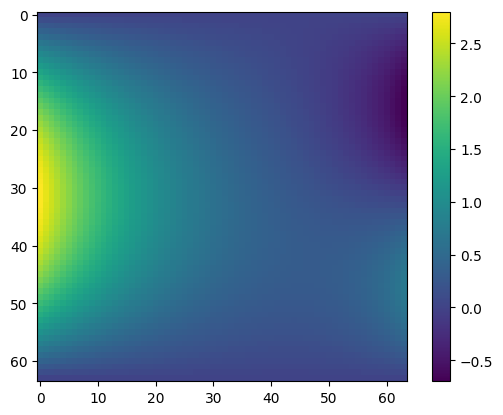

In [ ]:
initial_alpha1, initial_alpha2 = 0.78, 0.43
min_alpha, max_alpha = -5, 5
scaled_alpha1 = initial_alpha1 * (max_alpha - min_alpha) + min_alpha
scaled_alpha2 = initial_alpha2 * (max_alpha - min_alpha) + min_alpha
solution, parameters = generator.solve_laplace(scaled_alpha1, scaled_alpha2)

def normalize_to_0_1(arr):
    arr_min = arr.min()
    arr_max = arr.max()
    return (arr - arr_min) / (arr_max - arr_min)

plt.imshow(solution)
plt.colorbar()

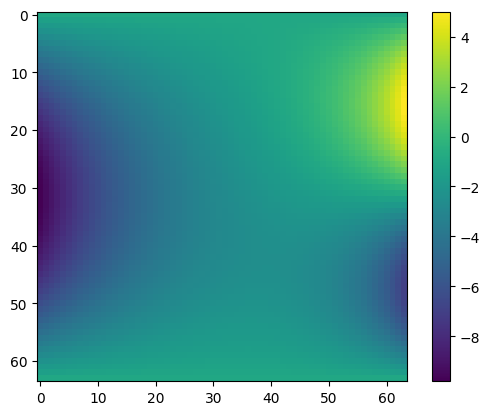

In [ ]:
def normalize_to_neg_one_to_one(img):
    return img * 2 - 1

def unnormalize_to_zero_to_one(t):
    return (t + 1) * 0.5

norm = normalize_to_neg_one_to_one(solution)
sol = unnormalize_to_zero_to_one(norm)
plt.imshow(norm)
plt.colorbar()

# Dataset DLR

In [27]:
from netCDF4 import Dataset
import os
import numpy as np

In [28]:
fname = "../data/dlr_airfoils/test/Snap_Case0060_M0.63047_AoA1.64198"
nc_fid = Dataset(fname, 'r')
x = nc_fid.variables["x"][: 597]
z = nc_fid.variables["z"][: 597]
cp = nc_fid.variables["cp"][: 597]
mach = nc_fid.Mach
alpha = nc_fid.Alpha    

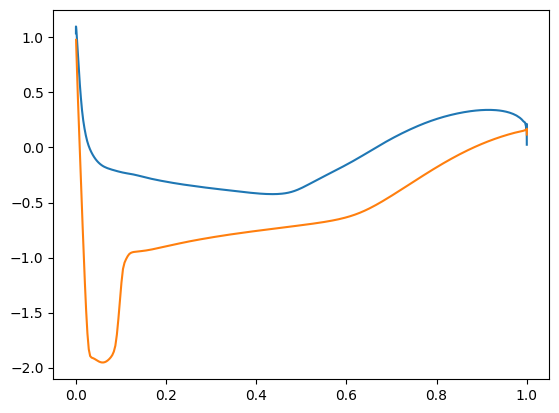

In [29]:
import matplotlib.pyplot as plt

plt.plot(x[:597//2], cp[:597//2])#, marker='.')
plt.plot(x[597//2:], cp[597//2:])#, marker='.', c='green')

In [30]:
x[297], z[297], x[298], z[298], x[299], z[299]

(1.0, -0.0005455, 1.0, -0.00036365, 1.0, -0.0001818)

In [31]:
x[:597//2].shape, x[597//2:].shape

((298,), (299,))

shape a tener en el dataset:  
(N_airfoils, 2, Num_puntos / 2)  
2 --> parte de arriba y parte de abajo  
Para la longitud de secuencia hay que tener en cuanta que el numero de puntos es impar, asi que hay que hacer algo ahi.

In [32]:
training_files = os.listdir("../data/dlr_airfoils/train/") 
training_files = list(map(lambda x: "../data/dlr_airfoils/train/" + x, training_files))
val_files = os.listdir("../data/dlr_airfoils/val/") 
val_files = list(map(lambda x: "../data/dlr_airfoils/val/" + x, val_files))
test_files = os.listdir("../data/dlr_airfoils/test")
test_files = list(map(lambda x: "../data/dlr_airfoils/test/" + x, test_files))
training_files = training_files #+ val_files
len(training_files), len(val_files), len(test_files)

(39, 20, 39)

In [35]:
def generate_arrays(files: list):
    airfoils, conditions = [], []
    for file_name in files:
        nc_fid = Dataset(file_name, 'r')
        cp = nc_fid.variables["cp"][: 597]
        mach = nc_fid.Mach
        alpha = nc_fid.Alpha
        # cp_lower = cp[:298]
        # cp_upper = cp[299:]
        conditions.append([mach, alpha])
        # airfoils.append(np.vstack((cp_lower, cp_upper)))
        airfoils.append(cp)
        # print(np.vstack((cp_lower, cp_upper)).shape)
    
    airfoils = np.stack(airfoils, axis=0)
    airfoils = airfoils[:, np.newaxis, :]  # add channel dimension
    conditions = np.array(conditions)

    return airfoils, conditions

In [36]:
airfoils_train, conditions_train = generate_arrays(training_files)
airfoils_train.shape, conditions_train.shape

((39, 1, 597), (39, 2))

In [37]:
np.save("../data/dlr_airfoils/cp_train_1d", np.array(airfoils_train))
np.save("../data/dlr_airfoils/conditions_train_1d", conditions_train)

In [39]:
airfoils_test, conditions_test = generate_arrays(test_files)
np.save("../data/dlr_airfoils/cp_test_1d", np.array(airfoils_test))
np.save("../data/dlr_airfoils/conditions_test_1d", conditions_test)

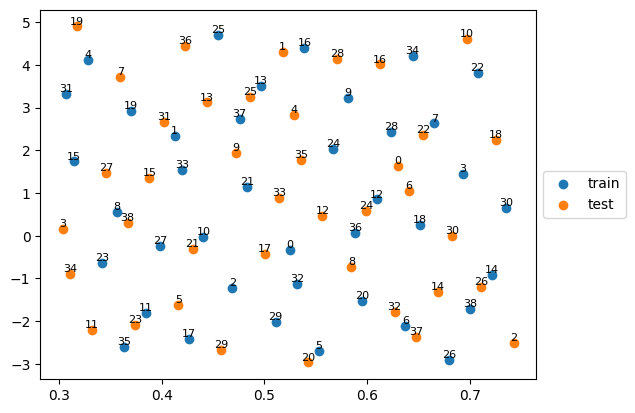

In [40]:
plt.scatter(conditions_train[:, 0], conditions_train[:, 1], label="train")
plt.scatter(conditions_test[:, 0], conditions_test[:, 1], label="test")
for i in range(conditions_train.shape[0]):
    plt.text(conditions_train[i, 0], conditions_train[i, 1]+0.005, str(i), fontsize=8, color='black', ha='center', va='bottom')

for i in range(conditions_train.shape[0]):
    plt.text(conditions_test[i, 0], conditions_test[i, 1]+0.005, str(i), fontsize=8, color='black', ha='center', va='bottom')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

quiero primero usar para img to img el 34 de train para ir al 16 de test.  
Si no va bien, interpolar entre 34 y 9 y usar esa interpolacion para img to img para las condiciones de test del 16

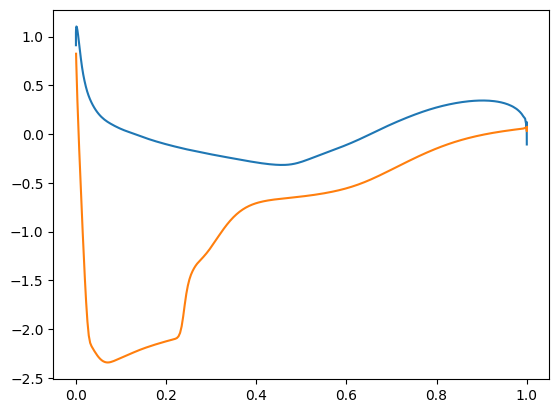

In [ ]:
idx = 34
cp = airfoils_train[idx]

plt.plot(x[:597//2], cp[0])#, marker='.')
plt.plot(x[597//2:], cp[1])

## See the predictions of the model

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# from netCDF4 import Dataset

In [58]:
data = np.load("../data/dlr_airfoils/cp_train.npy")
# at the moment the model expects inputs in [0, 1], like grayscale images 
data_min, data_max = data.min(), data.max()
data_mean, data_std = data.mean(), data.std()
# data = (data - data_min) / (data_max - data_min)

In [65]:
preds = torch.load("../results/dlr/FM_dit_xxs_1/test_predictions_ema.pt", weights_only=True, map_location='cpu')
preds = preds.view(-1, 2, 298)
true_values = np.load("../data/dlr_airfoils/cp_test.npy")#.flatten()
# true_values = (true_values - data_min) / (data_max - data_min) 
parameters = np.load("../data/dlr_airfoils/conditions_test.npy")

In [66]:
preds.shape, true_values.shape

(torch.Size([39, 2, 298]), (39, 2, 298))

In [ ]:
# reescale predictions
preds = preds * (data_max - data_min) + data_min
# preds = preds * data_std + data_mean

In [68]:
from cetaceo.evaluators import RegressionEvaluator
evaluator = RegressionEvaluator(tolerance=1e-5)
evaluator(true_values, preds)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0036
rmse: 0.0597
mae: 0.0285
mre: 34.7589%
ae_95: 0.0841
ae_99: 0.2411
r2: 0.9853
l2_error: 0.1017


In [48]:
data = np.load("../data/dlr_airfoils/cp_train_1d.npy")
# at the moment the model expects inputs in [0, 1], like grayscale images 
data_min, data_max = data.min(), data.max()
data_mean, data_std = data.mean(), data.std()
preds = torch.load("../results/dlr/FM_dit_xxs_1_one_channel/test_predictions_ema.pt", weights_only=True, map_location='cpu')
preds = preds * data_std + data_mean
evaluator = RegressionEvaluator(tolerance=1e-5)
evaluator(airfoils_test, preds)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0056
rmse: 0.0750
mae: 0.0157
mre: 10.7147%
ae_95: 0.0464
ae_99: 0.2864
r2: 0.9768
l2_error: 0.1313


### Eval DiT

In [ ]:
import pyLOM
import torch
preds = torch.load("../results/dlr/dit_S1_first/test_predictions_ema.pt", weights_only=True, map_location='cpu').squeeze()

data_train = pyLOM.Dataset.load("/home/d.ramos/Datos_DLR_pylom/NRL7301_TRAIN.h5")
data_test = pyLOM.Dataset.load("/home/d.ramos/Datos_DLR_pylom/NRL7301_TEST.h5")
cp = data_train["CP"].T
cp_min = cp.min()
cp_max = cp.max()
preds_unnormalized = preds.numpy() * (cp_max - cp_min) + cp_min
cp_test = data_test["CP"].T
# cp = cp[..., :-1]
preds_unnormalized.shape, cp.shape

((39, 597), (39, 597))

In [ ]:
from cetaceo.evaluators import RegressionEvaluator
evaluator = RegressionEvaluator(tolerance=1e-5)
evaluator(cp_test, preds_unnormalized)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0027
rmse: 0.0516
mae: 0.0204
mre: 14.9347%
ae_95: 0.0539
ae_99: 0.1960
r2: 0.9890
l2_error: 0.0890


In [ ]:
import pandas as pd


all_metrics = []
sizes = ["XS_1", "B1", "S1_first", "L1", "XL_1", "S_1_no_scheduler_grad_norm_learn_sigma", "S_1_no_scheduler_grad_norm"]
for size in sizes:
    preds = torch.load(f"../results/dlr/dit_{size}/sample-7.pt", weights_only=True, map_location='cpu').squeeze()
    preds_unnormalized = preds.numpy() * (cp_max - cp_min) + cp_min
    evaluator = RegressionEvaluator(tolerance=1e-5)
    metrics = evaluator(cp_test, preds_unnormalized)
    all_metrics.append(metrics)

df_metrics = pd.DataFrame(all_metrics, index=sizes)
df_metrics = df_metrics.sort_values(by="r2", ascending=False)
df_metrics

,mse,rmse,mae,mre,ae_95,ae_99,r2,l2_error
S_1_no_scheduler_grad_norm,0.002636,0.051338,0.020553,18.052548,0.052916,0.207344,0.989134,0.088272
S1_first,0.002651,0.051488,0.020056,20.614547,0.052665,0.194617,0.989071,0.088654
XL_1,0.002966,0.054461,0.019150,15.423095,0.052926,0.219849,0.987772,0.093849
S_1_no_scheduler_grad_norm_learn_sigma,0.002970,0.054498,0.023101,26.956119,0.064406,0.234397,0.987755,0.093318
B1,0.003037,0.055109,0.019801,27.487438,0.051352,0.258881,0.987479,0.094268
XS_1,0.005148,0.071750,0.034250,33.407774,0.099312,0.278810,0.978776,0.121705
L1,0.013234,0.115038,0.029665,25.257867,0.096671,0.484121,0.945441,0.199892


### Evaluate different models

In [ ]:
import pandas as pd

models_dirs = [
    "../results/dlr/dlr_big_bs_8_less_data",
    "../results/dlr/dlr_small_less_data_8_attn_heads",
    "../results/dlr/dlr_small_full_attn",
    "../results/dlr/dlr_tiny_less_data",
    "../results/dlr/dlr_small_bs_8_less_data", 
    "../results/dlr/dlr_very_big_less_data",
    "../results/dlr/dlr_huge",
    "../results/dlr/dlr_small_bs_16",
    "../results/dlr/dlr_small_pred_v",
    "../results/dlr/dlr_big_snr_5",
    "../results/dlr/dlr_very_big_snr_5_bs_4",
    "../results/dlr/dlr_very_big_snr_5_bs_4_02_drop_prob",
    "../results/dlr/dlr_very_big_snr_5_adaLN-Zero",
    "../results/dlr/dlr_very_big_snr_5_adaLN-Zero_v2",
    "../results/dlr/dlr_big_snr_5_adaLN-Zero_v2",
    "../results/dlr/dlr_medium_snr_5_adaLN-Zero_v2",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler_full_attn",
    "../results/dlr/dlr_snr_5_lr_scheduler_95_ema_decay",
    "../results/dlr/dlr_snr_5_lr_scheduler_98_ema_decay_self_condition",
    # "../results/dlr/",
    # "../results/dlr/",
    # "../results/dlr/",
    # "../results/dlr/",

]
model_names = [path.split('/')[-1] for path in models_dirs]

In [ ]:
def evaluate_predictions(reference_data, predictions):
    evaluator = RegressionEvaluator(tolerance=1e-5)
    return evaluator(reference_data, predictions)

def load_pred(folder_path, data_min, data_max):
    try:
        preds = torch.load(f"{folder_path}/test_predictions.pt", map_location='cpu')
    except:
        preds = torch.load(f"{folder_path}/test_predictions_ema.pt", weights_only=True)
    preds = preds.view(-1, 2, 298)
    preds = preds * (data_max - data_min) + data_min
    return preds

dfs = [
    pd.DataFrame(
        evaluate_predictions(true_values, load_pred(model_path, data_min, data_max)),
        index=[i],
    )
    for i, model_path in enumerate(models_dirs)
]

/tmp/ipykernel_625414/3469417902.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  preds = torch.load(f"{folder_path}/test_predictions.pt", map_location='cpu')


In [ ]:
df = pd.concat(dfs)
df['model_name'] = model_names
df = df.sort_values(by='mse')
df

,mse,rmse,mae,mre,ae_95,ae_99,r2,l2_error,model_name
16,0.001938,0.044022,0.012300,8.399797,0.033174,0.196191,0.992013,0.075759,dlr_snr_5_adaLN-Zero_lr_scheduler
18,0.002096,0.045786,0.012477,10.247554,0.033921,0.218969,0.991361,0.078947,dlr_snr_5_lr_scheduler_95_ema_decay
17,0.002280,0.047748,0.013249,8.485401,0.037279,0.211746,0.990604,0.082220,dlr_snr_5_adaLN-Zero_lr_scheduler_full_attn
14,0.002295,0.047904,0.017875,15.440786,0.048376,0.221312,0.990543,0.082447,dlr_big_snr_5_adaLN-Zero_v2
9,0.002876,0.053630,0.020037,15.038114,0.059022,0.242225,0.988147,0.092445,dlr_big_snr_5
13,0.003082,0.055511,0.019255,14.146060,0.051701,0.248111,0.987301,0.095074,dlr_very_big_snr_5_adaLN-Zero_v2
12,0.003178,0.056370,0.021379,15.495439,0.061101,0.267345,0.986905,0.096844,dlr_very_big_snr_5_adaLN-Zero
5,0.004205,0.064845,0.026348,18.677776,0.075729,0.260217,0.982671,0.111456,dlr_very_big_less_data
6,0.004690,0.068486,0.027672,25.848567,0.075297,0.312108,0.980670,0.115730,dlr_huge
4,0.004711,0.068637,0.031389,21.831605,0.091315,0.325388,0.980585,0.117637,dlr_small_bs_8_less_data


evaluate single model

In [ ]:
files = [
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema_30k.pt",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema_40k.pt",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema_50k.pt",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema_60k.pt",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema_70k_v2.pt",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema_80k.pt",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema_100k.pt",
    "../results/dlr/dlr_snr_5_adaLN-Zero_lr_scheduler/test_predictions_ema.pt",
]


def evaluate_predictions(reference_data, predictions):
    evaluator = RegressionEvaluator(tolerance=1e-5)
    return evaluator(reference_data, predictions)

def load_pred(file_path, data_min, data_max):
    preds = torch.load(file_path, map_location='cpu')
    preds = preds.view(-1, 2, 298)
    preds = preds * (data_max - data_min) + data_min
    return preds

dfs = [
    pd.DataFrame(
        evaluate_predictions(true_values, load_pred(preds_path, data_min, data_max)),
        index=[i],
    )
    for i, preds_path in enumerate(files)
]
df = pd.concat(dfs)
model_names = [name.split('/')[-1].split(".")[0] for name in files]
df['model_name'] = model_names
df = df.sort_values(by='mse')
df

/tmp/ipykernel_625414/2509332990.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  preds = torch.load(file_path, map_location='cpu')


,mse,rmse,mae,mre,ae_95,ae_99,r2,l2_error,model_name
7,0.001938,0.044022,0.012300,8.399797,0.033174,0.196191,0.992013,0.075759,test_predictions_ema
5,0.002050,0.045282,0.013268,8.740916,0.040764,0.218373,0.991550,0.078172,test_predictions_ema_80k
6,0.002153,0.046397,0.012716,7.672875,0.035638,0.225936,0.991128,0.079676,test_predictions_ema_100k
3,0.002170,0.046586,0.016378,11.698275,0.045722,0.217328,0.991056,0.080478,test_predictions_ema_60k
2,0.002274,0.047688,0.018921,16.022234,0.055526,0.232451,0.990628,0.082115,test_predictions_ema_50k
1,0.002276,0.047705,0.021477,38.114481,0.057220,0.226822,0.990621,0.082216,test_predictions_ema_40k
4,0.002278,0.047725,0.015477,11.117452,0.045282,0.226645,0.990613,0.082024,test_predictions_ema_70k_v2
0,0.002330,0.048266,0.023334,17.942935,0.062151,0.202132,0.990399,0.083271,test_predictions_ema_30k


In [ ]:
fname = "../data/dlr_airfoils/test/Snap_Case0060_M0.63047_AoA1.64198"
nc_fid = Dataset(fname, 'r')
x = nc_fid.variables["x"][: 597]
x_lower = x[:298]
x_upper = x[299:]
x = np.concatenate((x_lower, x_upper))

In [ ]:
POINTS_PER_AIRFOIL = 298 * 2

# Create a 4x5 grid for 20 airfoils
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()  # Flatten to make indexing easier

for airfoil_idx in range(20):
    ax = axes[airfoil_idx]
    # airfoil_idx += 19
    
    # Get data for current airfoil
    cp_pred = preds[airfoil_idx].flatten()
    cp_true = true_values[airfoil_idx].flatten()
    conditions = parameters[airfoil_idx]
    
    # Plot on current subplot
    ax.plot(x, cp_true, label="true cp", c='blue', linestyle='dashed')
    ax.plot(x, cp_pred, label="predicted cp", c='orange', linestyle='dashed')
    ax.set_title(f"Airfoil {airfoil_idx}: α={conditions[1]:.2f}°, M={conditions[0]:.2f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('cp')

plt.tight_layout()
plt.show()

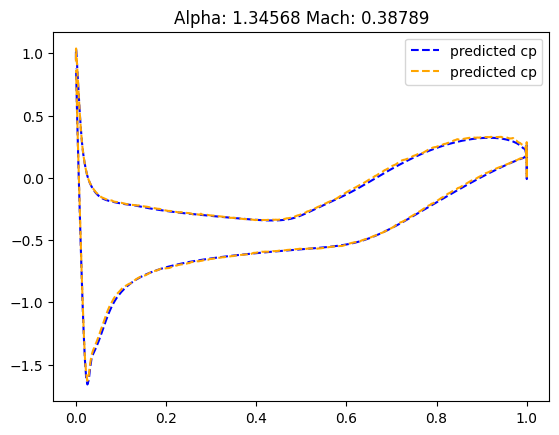

In [ ]:
POINTS_PER_AIRFOIL = 298 * 2
airfoil_idx = 15
# cp_pred = preds[POINTS_PER_AIRFOIL*airfoil_idx:POINTS_PER_AIRFOIL*(airfoil_idx + 1)]
# cp_true = true_values[POINTS_PER_AIRFOIL*airfoil_idx:POINTS_PER_AIRFOIL*(airfoil_idx + 1)]
cp_pred = preds[airfoil_idx].flatten()
cp_true = true_values[airfoil_idx].flatten()
conditions = parameters[airfoil_idx]
# plt.scatter(x, cp_true, marker='.', label="true cp")
# plt.scatter(x, cp_pred, marker='.', label="predicted cp")
plt.plot(x, cp_true, label="predicted cp", c='blue', linestyle='dashed')
plt.plot(x, cp_pred, label="predicted cp", c='orange', linestyle='dashed')
plt.title(f"Alpha: {conditions[1]} Mach: {conditions[0]}")
plt.legend()

## Predicciones con solo un canal

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
data = np.load("../data/dlr_airfoils/cp_train.npy")
# at the moment the model expects inputs in [0, 1], like grayscale images 
data_min, data_max = data.min(), data.max()
data = data.reshape(data.shape[0], 1, -1)
# data = (data - data_min) / (data_max - data_min)
preds = torch.load("../results/dlr/dlr_snr_5_adaLN-Zero_v2_one_channel/test_predictions_ema.pt", weights_only=True)
preds = preds.view(-1, 1, 596)
true_values = np.load("../data/dlr_airfoils/cp_test.npy")#.flatten()
# true_values = (true_values - data_min) / (data_max - data_min) 
parameters = np.load("../data/dlr_airfoils/conditions_test.npy")
true_values = true_values.reshape(true_values.shape[0], 1, -1)
preds.shape, true_values.shape

(torch.Size([39, 1, 596]), (39, 1, 596))

In [ ]:
preds = preds * (data_max - data_min) + data_min

In [ ]:
from cetaceo.evaluators import RegressionEvaluator

evaluator = RegressionEvaluator(tolerance=1e-5)
evaluator(true_values, preds)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0209
rmse: 0.1446
mae: 0.0597
mre: 93.4043%
ae_95: 0.3287
ae_99: 0.7202
r2: 0.9139
l2_error: 0.2499


## Gunet predictions

In [ ]:
import pyLOM
import numpy as np
import matplotlib.pyplot as plt
import json

In [ ]:
predictions_file = "../results/dlr/solo_gunet_L_with_attn/predictions.npz"
results = np.load(predictions_file)
preds = results["predictions"]
true_values = results["targets"]
with open("../results/dlr/solo_gunet_L_with_attn/norm_coefficients.json") as f:
    coeffs = json.load(f)
cp_min, cp_max = coeffs["cp_min"], coeffs["cp_max"]
preds = preds * (cp_max - cp_min) + cp_min
true_values = true_values * (cp_max - cp_min) + cp_min
preds.shape, true_values.shape

((39, 597), (39, 597))

In [ ]:
from cetaceo.evaluators import RegressionEvaluator

evaluator = RegressionEvaluator(tolerance=1e-5)
evaluator(true_values, preds)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0017
rmse: 0.0418
mae: 0.0185
mre: 17.9650%
ae_95: 0.0605
ae_99: 0.1702
r2: 0.9928
l2_error: 0.0720


In [ ]:
data_test = pyLOM.Dataset.load("/home/d.ramos/Datos_DLR_pylom/NRL7301_TEST.h5")
x = data.xyz[:, 0]
parameters = np.vstack((data_test.get_variable("Mach"), data_test.get_variable("AoA"))).T
x.shape, parameters.shape

((597,), (39, 2))

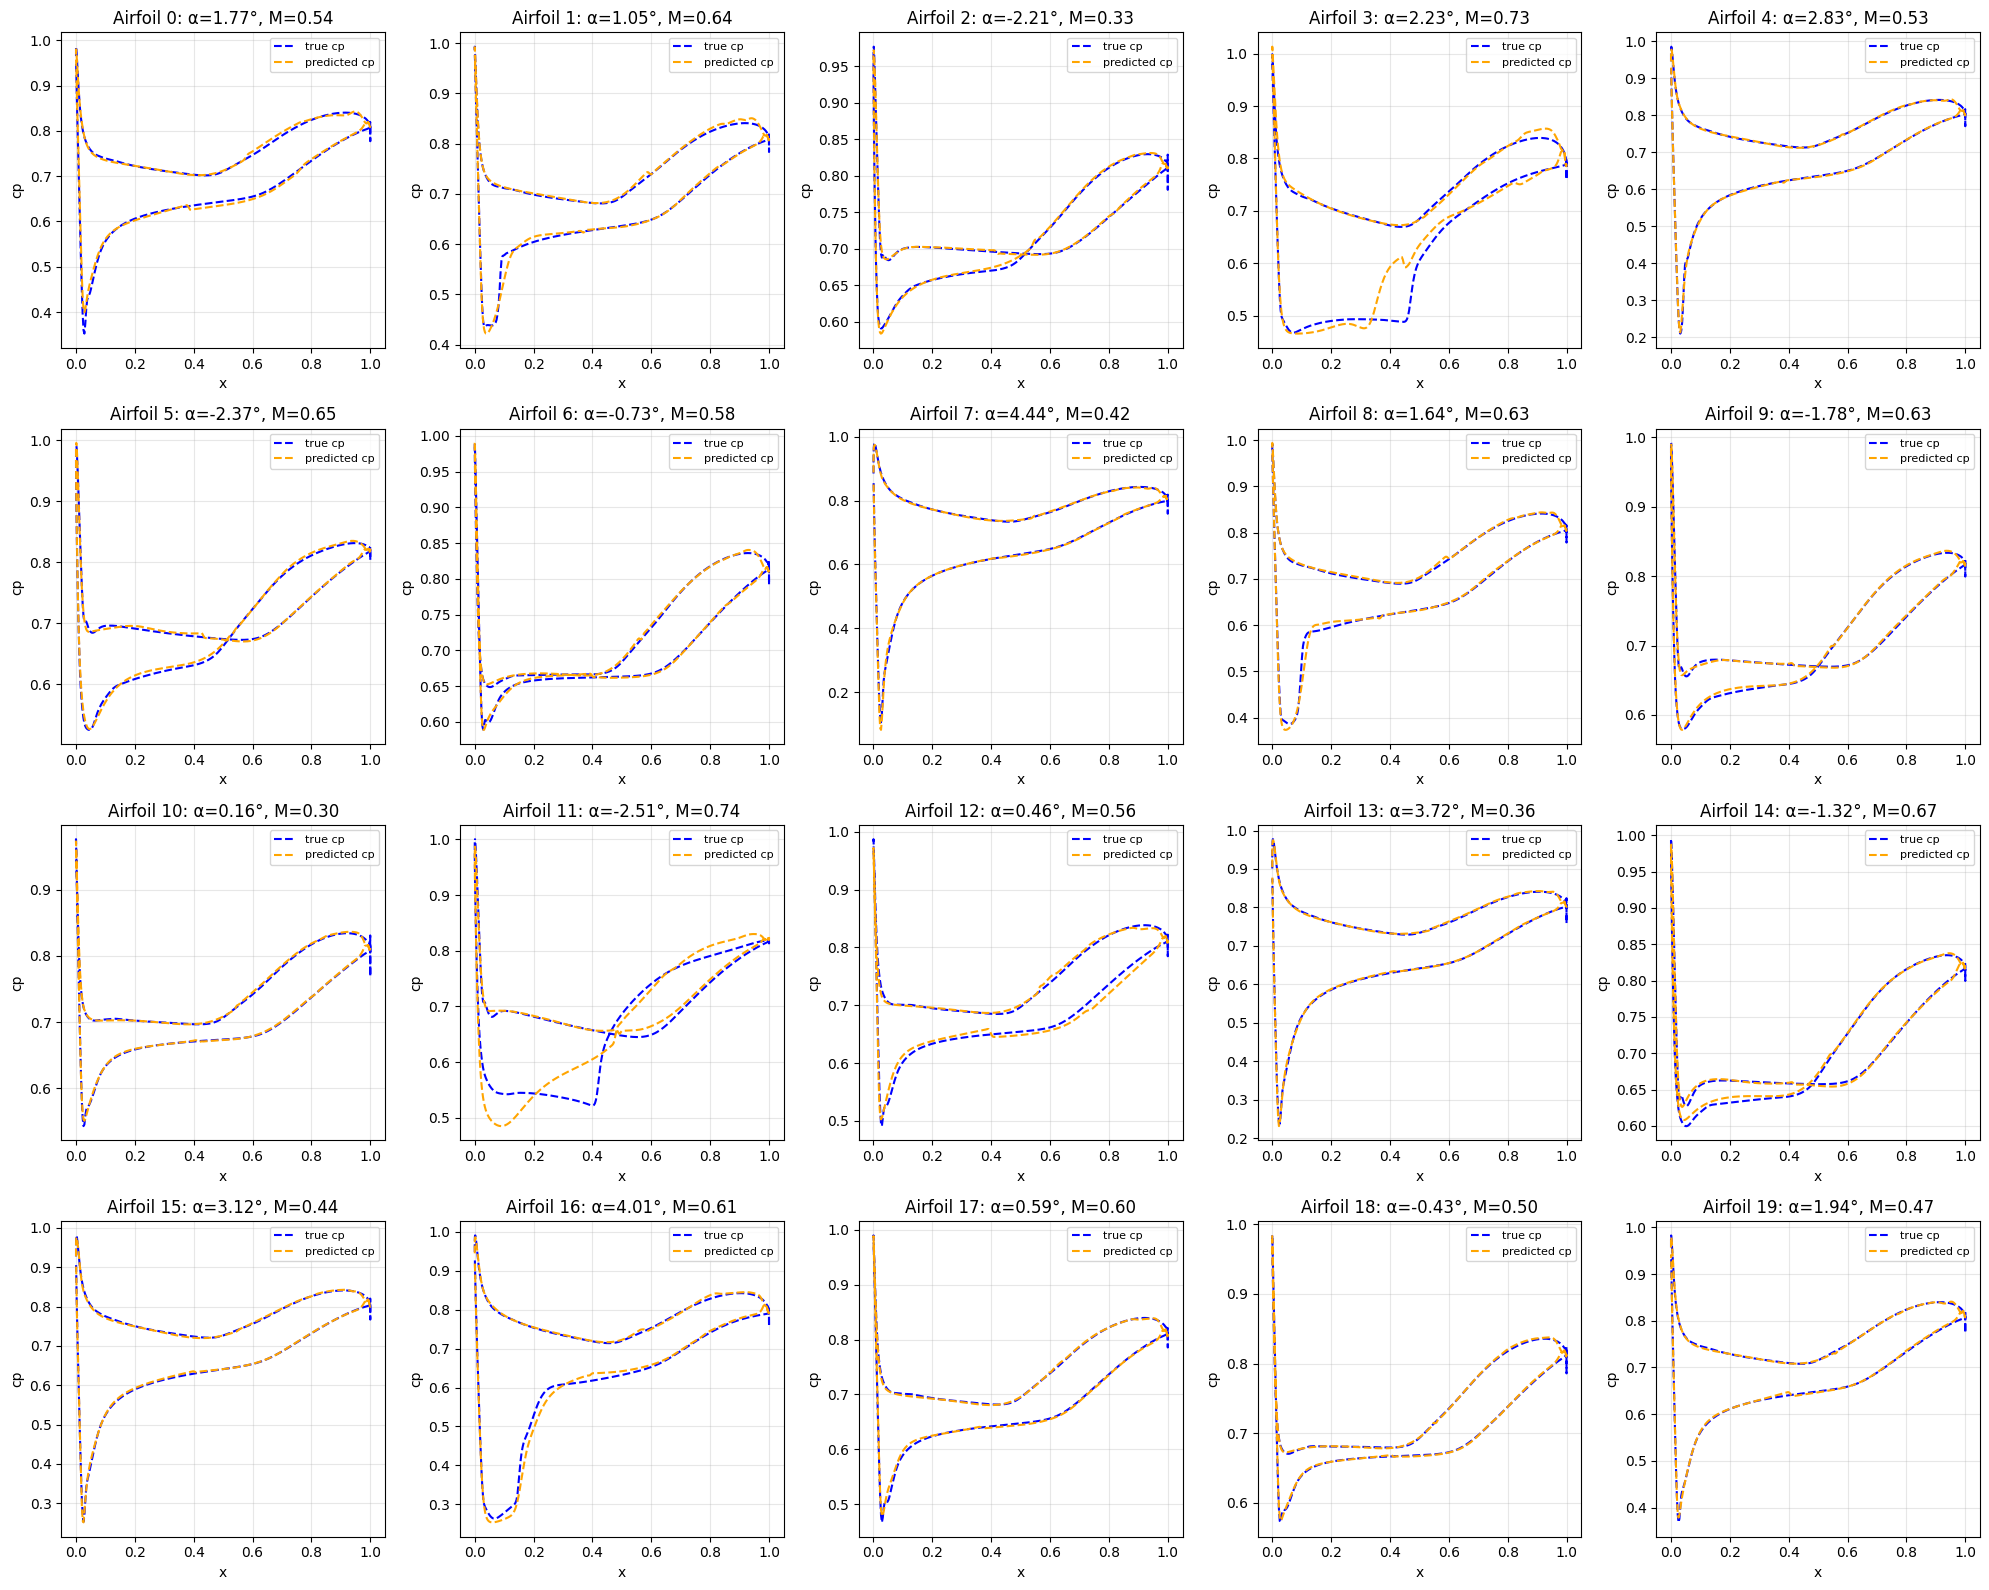

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()  # Flatten to make indexing easier

for airfoil_idx in range(20):
    ax = axes[airfoil_idx]
    # airfoil_idx += 19
    
    # Get data for current airfoil
    cp_pred = preds[airfoil_idx].flatten()
    cp_true = true_values[airfoil_idx].flatten()
    conditions = parameters[airfoil_idx]
    
    # Plot on current subplot
    ax.plot(x, cp_true, label="true cp", c='blue', linestyle='dashed')
    ax.plot(x, cp_pred, label="predicted cp", c='orange', linestyle='dashed')
    ax.set_title(f"Airfoil {airfoil_idx}: α={conditions[1]:.2f}°, M={conditions[0]:.2f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('cp')

plt.tight_layout()
plt.show()

# Non-linear equation dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class AnalyticalFunctionDataset:
    def __init__(self, nx=64, ny=64, x_range=(0, 2*np.pi), y_range=(0, 2*np.pi)):
        """
        Initialize the analytical function dataset generator.
        
        Parameters:
        - nx, ny: Number of grid points in x and y directions
        - x_range, y_range: Domain ranges for x and y coordinates
        """
        self.nx = nx
        self.ny = ny
        self.x_range = x_range
        self.y_range = y_range
        
        # Create coordinate grids
        x = np.linspace(x_range[0], x_range[1], nx)
        y = np.linspace(y_range[0], y_range[1], ny)
        self.X, self.Y = np.meshgrid(x, y)
        
        print(f"Grid initialized: {nx}x{ny}")
        print(f"X domain: [{x_range[0]:.2f}, {x_range[1]:.2f}]")
        print(f"Y domain: [{y_range[0]:.2f}, {y_range[1]:.2f}]")
    
    def evaluate_function(self, alpha1, alpha2):
        """
        Evaluate a complex nonlinear function with chaotic behavior:
        f(x,y) = α₁*sin(α₂*x + y)*cos(x*y/α₁) + α₂*exp(-((x-π)² + (y-π)²)/(2*α₁²))*sin(α₁*x*y)
        
        Parameters:
        - alpha1, alpha2: Function parameters
        
        Returns:
        - result: 2D array with function values
        - parameters: dict with parameter values
        """
        # Avoid division by zero
        alpha1_safe = alpha1 if abs(alpha1) > 0.1 else 0.1 * np.sign(alpha1) if alpha1 != 0 else 0.1
        
        # Term 1: Coupled oscillations with frequency modulation
        term1 = alpha1 * np.sin(alpha2 * self.X + self.Y) * np.cos(self.X * self.Y / alpha1_safe)
        
        # Term 2: Gaussian-modulated nonlinear interaction
        gaussian = np.exp(-((self.X - np.pi)**2 + (self.Y - np.pi)**2) / (2 * alpha1_safe**2))
        term2 = alpha2 * gaussian * np.sin(alpha1 * self.X * self.Y / 5.0)  # Scale down the product to avoid extreme oscillations
        
        # Term 3: Add some chaos with a nonlinear combination
        term3 = 0.3 * np.tanh(alpha1 * np.sin(2*self.X) + alpha2 * np.cos(3*self.Y))
        
        # Term 4: Interference patterns
        term4 = 0.2 * alpha1 * alpha2 * np.sin(self.X + alpha2) * np.sin(self.Y + alpha1) / (1 + 0.1 * (self.X**2 + self.Y**2))
        
        result = term1 + term2 + term3 + term4
        
        parameters = {'alpha1': alpha1, 'alpha2': alpha2}
        
        return result, parameters
    
    def generate_dataset(self, n_samples, alpha1_range=(-2.0, 2.0), alpha2_range=(-2.0, 2.0), 
                        random_seed=42):
        """
        Generate a dataset of function evaluations.
        
        Parameters:
        - n_samples: Number of samples to generate
        - alpha1_range, alpha2_range: Ranges for parameter sampling
        - random_seed: Random seed for reproducibility
        
        Returns:
        - solutions: Array of shape (n_samples, ny, nx)
        - parameters: Array of shape (n_samples, 2) with [alpha1, alpha2]
        """
        np.random.seed(random_seed)
        
        solutions = []
        parameters = []
        
        print(f"Generating {n_samples} samples...")
        
        for i in range(n_samples):
            # Sample parameters uniformly
            alpha1 = np.random.uniform(*alpha1_range)
            alpha2 = np.random.uniform(*alpha2_range)
            
            # Evaluate function
            solution, params = self.evaluate_function(alpha1, alpha2)
            
            solutions.append(solution)
            parameters.append([alpha1, alpha2])
            
            if (i + 1) % 100 == 0:
                print(f"Generated {i + 1}/{n_samples} samples")
        
        solutions = np.array(solutions)
        parameters = np.array(parameters)
        
        print(f"Dataset generation complete!")
        
        return solutions, parameters
    
    def generate_grid_dataset(self, alpha1_values, alpha2_values):
        """
        Generate a dataset on a regular grid of parameter values.
        
        Parameters:
        - alpha1_values: Array of alpha1 values
        - alpha2_values: Array of alpha2 values
        
        Returns:
        - solutions: Array of shape (n_alpha1 * n_alpha2, ny, nx)
        - parameters: Array of shape (n_alpha1 * n_alpha2, 2)
        """
        solutions = []
        parameters = []
        
        total_samples = len(alpha1_values) * len(alpha2_values)
        print(f"Generating {total_samples} samples on regular grid...")
        
        count = 0
        for alpha1 in alpha1_values:
            for alpha2 in alpha2_values:
                solution, params = self.evaluate_function(alpha1, alpha2)
                solutions.append(solution)
                parameters.append([alpha1, alpha2])
                
                count += 1
                if count % 100 == 0:
                    print(f"Generated {count}/{total_samples} samples")
        
        solutions = np.array(solutions)
        parameters = np.array(parameters)
        
        return solutions, parameters
    
    def save_dataset(self, solutions, parameters, filename_prefix="analytical_dataset"):
        """Save the dataset to numpy files."""
        np.save(f"{filename_prefix}_solutions.npy", solutions)
        np.save(f"{filename_prefix}_parameters.npy", parameters)
        
        print(f"\nDataset saved as {filename_prefix}_solutions.npy and {filename_prefix}_parameters.npy")
        print(f"Solutions shape: {solutions.shape}")
        print(f"Parameters shape: {parameters.shape}")
        print(f"Solutions range: [{solutions.min():.4f}, {solutions.max():.4f}]")
    
    def visualize_samples(self, solutions, parameters, n_samples=9, figsize=(12, 10)):
        """Visualize some samples from the dataset."""
        n_samples = min(n_samples, len(solutions))
        indices = np.random.choice(len(solutions), n_samples, replace=False)
        
        rows = int(np.ceil(np.sqrt(n_samples)))
        cols = int(np.ceil(n_samples / rows))
        
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        if n_samples == 1:
            axes = [axes]
        else:
            axes = axes.ravel() if n_samples > 1 else axes
        
        for i, idx in enumerate(indices):
            if i >= len(axes):
                break
                
            # im = axes[i].contourf(self.X, self.Y, solutions[idx], levels=50, cmap='RdBu_r')
            im = axes[i].imshow(solutions[idx], cmap='RdBu_r')
            axes[i].set_title(f'α₁={parameters[idx][0]:.2f}, α₂={parameters[idx][1]:.2f}')
            axes[i].set_xlabel('x')
            axes[i].set_ylabel('y')
            axes[i].set_aspect('equal')
            plt.colorbar(im, ax=axes[i])
        
        # Hide empty subplots
        for i in range(len(indices), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    
    def analyze_dataset(self, solutions, parameters):
        """Analyze the generated dataset."""
        print("\n" + "="*50)
        print("DATASET ANALYSIS")
        print("="*50)
        
        print(f"Function: Complex nonlinear function with multiple interacting terms")
        print(f"f(x,y) = α₁*sin(α₂*x + y)*cos(x*y/α₁) + α₂*exp(-((x-π)² + (y-π)²)/(2*α₁²))*sin(α₁*x*y/5)")
        print(f"       + 0.3*tanh(α₁*sin(2x) + α₂*cos(3y)) + 0.2*α₁*α₂*sin(x+α₂)*sin(y+α₁)/(1+0.1*(x²+y²))")
        print(f"Number of samples: {len(solutions)}")
        print(f"Grid size: {self.nx} × {self.ny}")
        print(f"Domain: x ∈ [{self.x_range[0]:.2f}, {self.x_range[1]:.2f}], y ∈ [{self.y_range[0]:.2f}, {self.y_range[1]:.2f}]")
        
        print(f"\nParameter Statistics:")
        print(f"α₁: min={parameters[:, 0].min():.3f}, max={parameters[:, 0].max():.3f}, mean={parameters[:, 0].mean():.3f}")
        print(f"α₂: min={parameters[:, 1].min():.3f}, max={parameters[:, 1].max():.3f}, mean={parameters[:, 1].mean():.3f}")
        
        print(f"\nFunction Values:")
        print(f"f(x,y): min={solutions.min():.3f}, max={solutions.max():.3f}, mean={solutions.mean():.3f}")
        print(f"Standard deviation: {solutions.std():.3f}")
        
        # Theoretical maximum (when both sin and cos are at their peaks)
        max_alpha1 = max(abs(parameters[:, 0].min()), abs(parameters[:, 0].max()))
        max_alpha2 = max(abs(parameters[:, 1].min()), abs(parameters[:, 1].max()))
        theoretical_max = max_alpha1 * max_alpha2
        print(f"Theoretical maximum: ±{theoretical_max:.3f}")

Grid initialized: 64x64
X domain: [0.00, 6.28]
Y domain: [0.00, 6.28]

METHOD 1: Random Parameter Sampling
Generating 1000 samples...
Generated 100/1000 samples
Generated 200/1000 samples
Generated 300/1000 samples
Generated 400/1000 samples
Generated 500/1000 samples
Generated 600/1000 samples
Generated 700/1000 samples
Generated 800/1000 samples
Generated 900/1000 samples
Generated 1000/1000 samples
Dataset generation complete!

Dataset saved as non_linear_extrapolate_solutions.npy and non_linear_extrapolate_parameters.npy
Solutions shape: (757, 64, 64)
Parameters shape: (757, 2)
Solutions range: [-8.4624, 7.8078]

DATASET ANALYSIS
Function: Complex nonlinear function with multiple interacting terms
f(x,y) = α₁*sin(α₂*x + y)*cos(x*y/α₁) + α₂*exp(-((x-π)² + (y-π)²)/(2*α₁²))*sin(α₁*x*y/5)
       + 0.3*tanh(α₁*sin(2x) + α₂*cos(3y)) + 0.2*α₁*α₂*sin(x+α₂)*sin(y+α₁)/(1+0.1*(x²+y²))
Number of samples: 757
Grid size: 64 × 64
Domain: x ∈ [0.00, 6.28], y ∈ [0.00, 6.28]

Parameter Statistics:
α

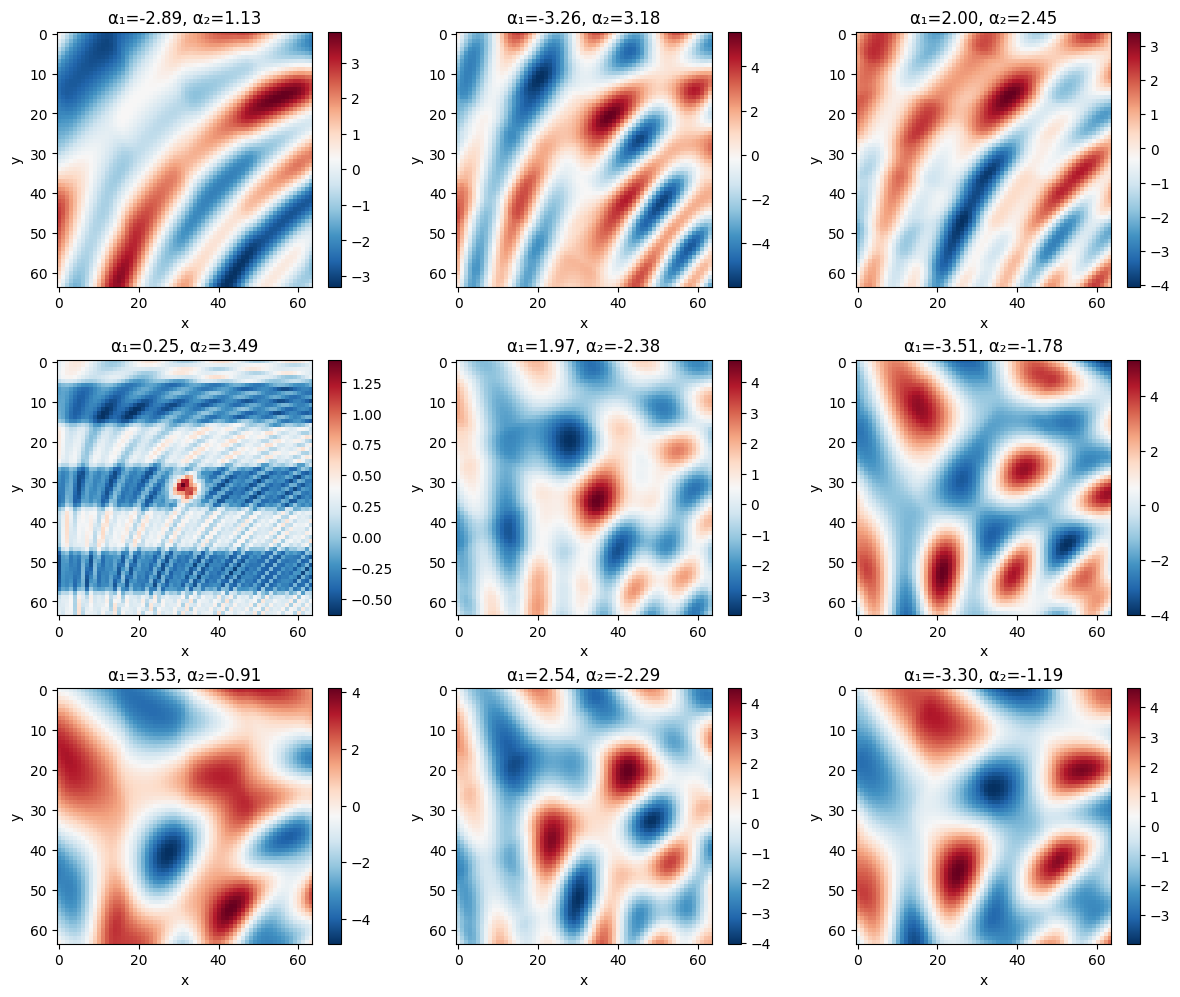

In [ ]:
generator = AnalyticalFunctionDataset(nx=64, ny=64, x_range=(0, 2*np.pi), y_range=(0, 2*np.pi))
    
    # Method 1: Random sampling
print("\n" + "="*50)
print("METHOD 1: Random Parameter Sampling")
print("="*50)

solutions_random, parameters_random = generator.generate_dataset(
    n_samples=1000,
    alpha1_range=(-4.0, 4.0),
    alpha2_range=(-4.0, 4.0)
)
mask_train_area = (parameters_random[:, 0] <= 2) & (parameters_random[:, 0] >= -2) & (parameters_random[:, 1] <= 2) & (parameters_random[:, 1] >= -2)
solutions_random = solutions_random[~mask_train_area]
parameters_random = parameters_random[~mask_train_area]

# Save random dataset
generator.save_dataset(solutions_random, parameters_random, "non_linear_extrapolate")

# Analyze dataset
generator.analyze_dataset(solutions_random, parameters_random)

# Visualize samples
generator.visualize_samples(solutions_random, parameters_random, n_samples=9)

# Method 2: Grid sampling (optional)
# print("\n" + "="*50)
# print("METHOD 2: Regular Grid Sampling")
# print("="*50)

# alpha1_grid = np.linspace(-2, 2, 10)
# alpha2_grid = np.linspace(-2, 2, 10)

# solutions_grid, parameters_grid = generator.generate_grid_dataset(alpha1_grid, alpha2_grid)

# # Save grid datase
# generator.save_dataset(solutions_grid, parameters_grid, "analytical_grid")

# # Analyze grid dataset
# generator.analyze_dataset(solutions_grid, parameters_grid)

# print("\n" + "="*50)
# print("DATASETS READY FOR CNN TRAINING!")
# print("="*50)

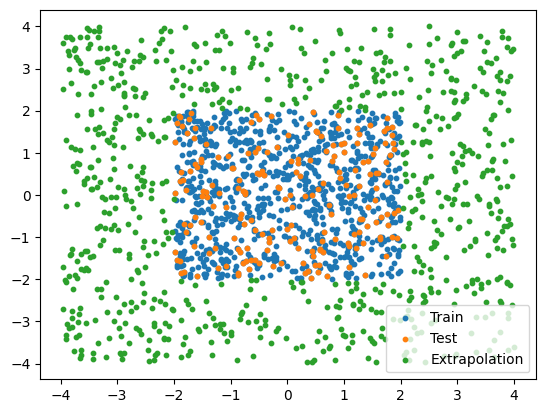

In [ ]:
parameters_train = np.load("../data/non_linear_eq/non_linear_train_parameters.npy")
parameters_test = np.load("../data/non_linear_eq/non_linear_test_parameters.npy")
paramters_extrapolated = np.load("../data/non_linear_eq/non_linear_extrapolate_parameters.npy")

plt.scatter(parameters_train[:, 0], parameters_train[:, 1], label="Train", s=10)
plt.scatter(parameters_test[:, 0], parameters_test[:, 1], label="Test", s=10)
plt.scatter(paramters_extrapolated[:, 0], paramters_extrapolated[:, 1], label="Extrapolation", s=10)
plt.legend()
plt.show()

In [ ]:
import torch 
import numpy as np
import matplotlib.pyplot as plt # RdBu_r

In [ ]:
data = np.load("../data/non_linear_eq/non_linear_train_solutions.npy")
# at the moment the model expects inputs in [0, 1], like grayscale images 
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)  # scale to [0, 1]
data = data[:, np.newaxis, :, :]  # add channel dimension   
parameters = np.load("../data/non_linear_eq/non_linear_train_parameters.npy")
# normalize parameters to [0, 1]
parameters_mean, parameters_std = parameters.mean(axis=0), parameters.std(axis=0)
parameters = (parameters - parameters_mean) / (parameters_std)

# load test data
test_data = np.load("../data/non_linear_eq/non_linear_test_solutions.npy")
test_data = (test_data - data_min) / (data_max - data_min) 
test_data = test_data[:, np.newaxis, :, :]
test_parameters = np.load("../data/non_linear_eq/non_linear_test_parameters.npy")
test_parameters = (test_parameters - parameters_mean) / (parameters_std)

In [ ]:
predictions = torch.load("../results/non_linear_eq_big_128_bs/test_predictions.pt")

/tmp/ipykernel_1188036/4002862812.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  predictions = torch.load("../results/non_linear_eq_big_128_bs/test_predictions.pt")


In [ ]:
def plot_images_grid(images, input_parameters):
    fig, axes = plt.subplots(int(np.sqrt(len(images))), int(np.sqrt(len(images))), figsize=(12,12))
    for i, ax in enumerate(axes.flat):
        im = ax.imshow(images[i].squeeze(), cmap="RdBu_r")
        ax.set_title(f"Alpha1={input_parameters[i][0].item():.2f}, Alpha2={input_parameters[i][1].item():.2f}")
        plt.colorbar(im, ax=ax)
        ax.axis('off')
    # plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.plot()

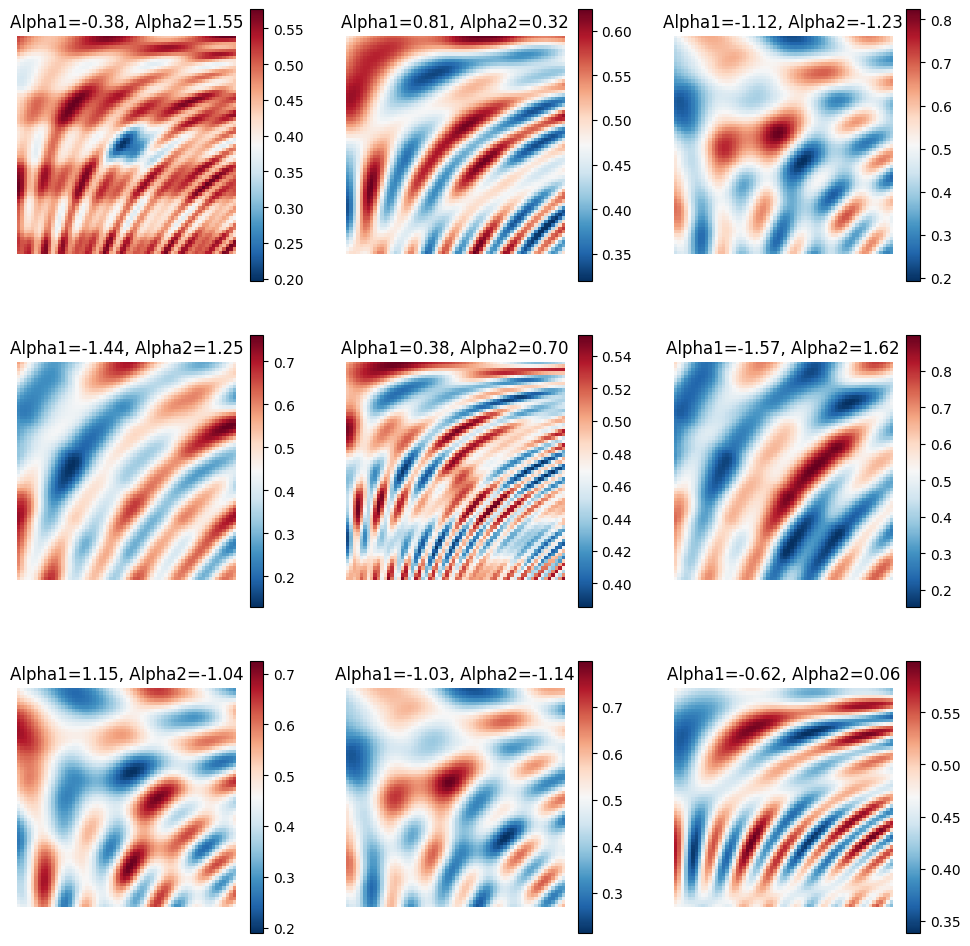

In [ ]:
num_images = 9
inputs_to_plot = test_parameters[:num_images]
real_values_to_plot = test_data[:num_images]
plot_images_grid(
    real_values_to_plot,
    inputs_to_plot,
)

In [ ]:
predictions = predictions.view(-1, 1, 64, 64)
predictions.shape

torch.Size([200, 1, 64, 64])

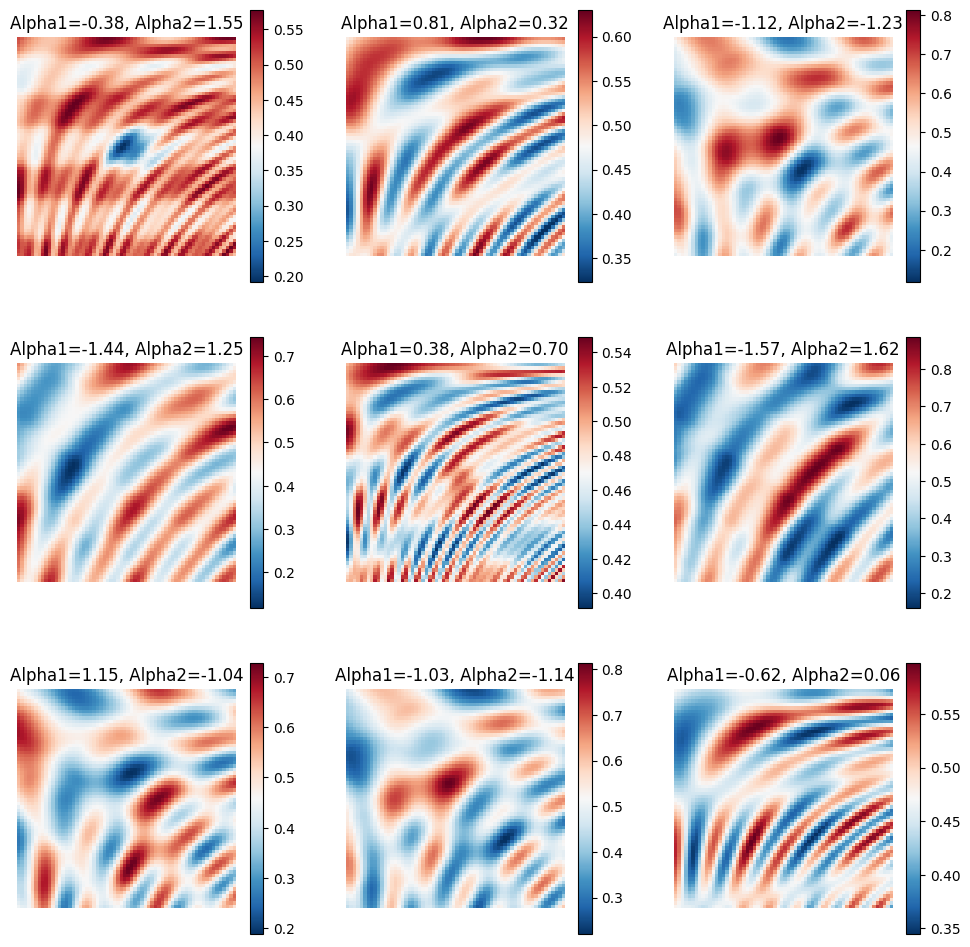

In [ ]:
inputs_to_plot = test_parameters[:num_images]
real_values_to_plot = test_data[:num_images]
plot_images_grid(
    predictions[:num_images],
    inputs_to_plot,
)

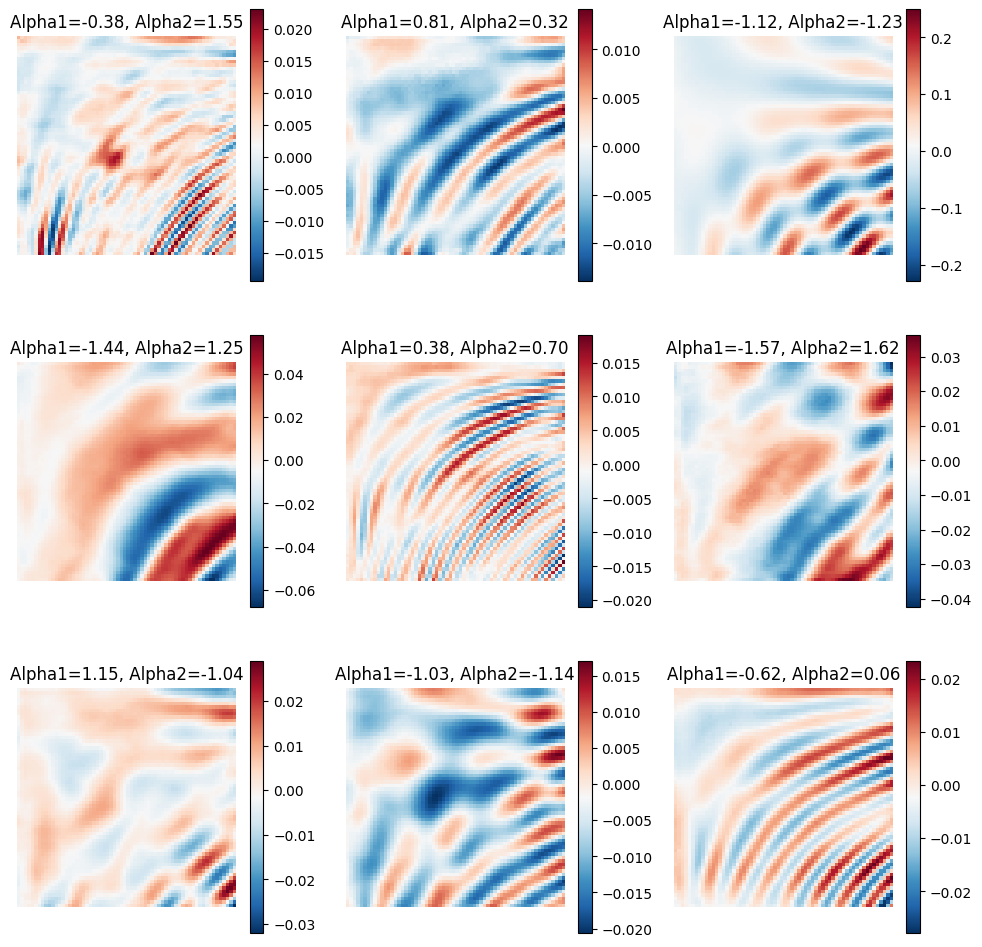

In [ ]:
plot_images_grid(
    real_values_to_plot - predictions[:num_images].numpy(),
    inputs_to_plot,
)

In [ ]:
data = np.load("../data/non_linear_eq/non_linear_train_solutions.npy")
# at the moment the model expects inputs in [0, 1], like grayscale images 
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)  # scale to [0, 1]
data = data[:, np.newaxis, :, :]  # add channel dimension   
parameters = np.load("../data/non_linear_eq/non_linear_train_parameters.npy")
# normalize parameters to [0, 1]
parameters_mean, parameters_std = parameters.mean(axis=0), parameters.std(axis=0)
parameters = (parameters - parameters_mean) / (parameters_std)

# load test data
test_data = np.load("../data/non_linear_eq/non_linear_extrapolate_solutions.npy")
test_data = (test_data - data_min) / (data_max - data_min) 
# test_data = test_data[:, np.newaxis, :, :]
test_parameters = np.load("../data/non_linear_eq/non_linear_extrapolate_parameters.npy")
# test_parameters = (test_parameters - parameters_mean) / (parameters_std)

In [ ]:
predictions = torch.load("../results/non_linear_eq_big_128_bs/extrapolation_predictions.pt")
predictions = predictions.view(-1, 64, 64).numpy()

/tmp/ipykernel_662931/517343730.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  predictions = torch.load("../results/non_linear_eq_big_128_bs/extrapolation_predictions.p

In [ ]:
maes = np.abs(test_data - predictions).mean(axis=(1, 2))
maes.shape

(757,)

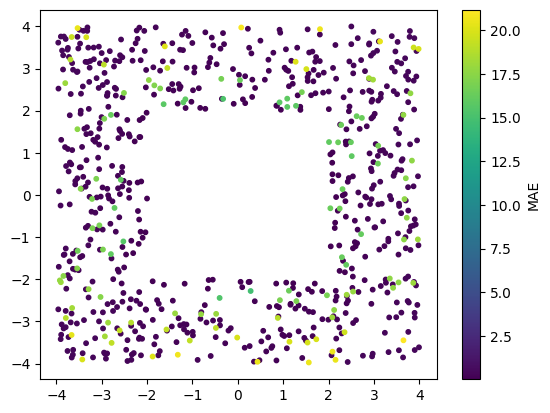

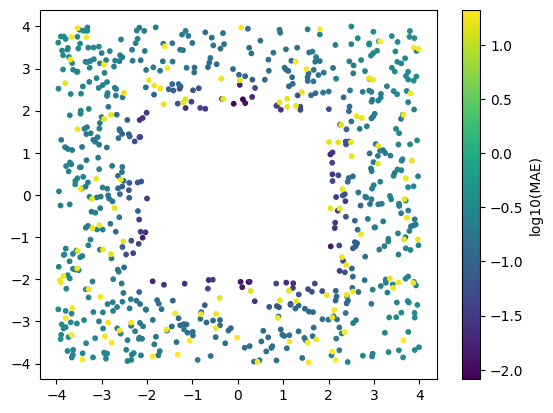

In [ ]:
sc = plt.scatter(test_parameters[:, 0], test_parameters[:, 1], s=10, c=maes)
plt.colorbar(sc, label="MAE")
plt.show()

plt.figure()
sc = plt.scatter(test_parameters[:, 0], test_parameters[:, 1], s=10, c=np.log10(maes + 1e-10))
plt.colorbar(sc, label="log10(MAE)")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have your test_parameters and maes arrays
# test_parameters = your_parameter_array
# maes = your_mae_values

# Option 1: Use a better colormap with improved contrast
plt.figure(figsize=(10, 8))
sc = plt.scatter(test_parameters[:, 0], test_parameters[:, 1], 
                s=15, c=maes, cmap='plasma', alpha=0.7)
plt.colorbar(sc, label="MAE")
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Parameter Space with MAE (Plasma Colormap)")
plt.grid(True, alpha=0.3)
plt.show()

# Option 2: Use log scale for color mapping (if MAE values span wide range)
plt.figure(figsize=(10, 8))
# Add small epsilon to avoid log(0) if you have zero values
maes_log = np.log10(maes + 1e-10)
sc = plt.scatter(test_parameters[:, 0], test_parameters[:, 1], 
                s=15, c=maes_log, cmap='viridis', alpha=0.8)
plt.colorbar(sc, label="log₁₀(MAE)")
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Parameter Space with log(MAE)")
plt.grid(True, alpha=0.3)
plt.show()

# Option 3: Use percentile-based color scaling
plt.figure(figsize=(10, 8))
# Clip extreme values to better show the bulk of the data
vmin, vmax = np.percentile(maes, [5, 95])
sc = plt.scatter(test_parameters[:, 0], test_parameters[:, 1], 
                s=15, c=maes, cmap='RdYlBu_r', 
                vmin=vmin, vmax=vmax, alpha=0.8)
plt.colorbar(sc, label="MAE", extend='both')
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Parameter Space with MAE (5th-95th percentile range)")
plt.grid(True, alpha=0.3)
plt.show()

# Option 4: Variable point sizes based on MAE + color
plt.figure(figsize=(10, 8))
# Normalize sizes (smaller MAE = larger points to highlight good regions)
sizes = 50 * (1 - (maes - maes.min()) / (maes.max() - maes.min())) + 5
sc = plt.scatter(test_parameters[:, 0], test_parameters[:, 1], 
                s=sizes, c=maes, cmap='coolwarm', 
                alpha=0.6, edgecolors='black', linewidth=0.1)
plt.colorbar(sc, label="MAE")
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Parameter Space (Size ∝ 1/MAE, Color = MAE)")
plt.grid(True, alpha=0.3)
plt.show()

# Option 5: Hexbin plot for density + average MAE
plt.figure(figsize=(10, 8))
hb = plt.hexbin(test_parameters[:, 0], test_parameters[:, 1], 
               C=maes, reduce_C_function=np.mean, 
               gridsize=30, cmap='plasma', alpha=0.8)
plt.colorbar(hb, label="Average MAE")
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Parameter Space - Hexbin with Average MAE")
plt.show()

# Option 6: Contour plot overlay
plt.figure(figsize=(12, 5))

# Left: scatter plot
plt.subplot(1, 2, 1)
sc = plt.scatter(test_parameters[:, 0], test_parameters[:, 1], 
                s=10, c=maes, cmap='plasma', alpha=0.7)
plt.colorbar(sc, label="MAE")
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Scatter Plot")
plt.grid(True, alpha=0.3)

# Right: scatter + contour
plt.subplot(1, 2, 2)
# Create a grid for interpolation
from scipy.interpolate import griddata
xi = np.linspace(test_parameters[:, 0].min(), test_parameters[:, 0].max(), 100)
yi = np.linspace(test_parameters[:, 1].min(), test_parameters[:, 1].max(), 100)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((test_parameters[:, 0], test_parameters[:, 1]), maes, 
              (Xi, Yi), method='cubic', fill_value=maes.mean())

# Plot contours
contour = plt.contourf(Xi, Yi, Zi, levels=20, cmap='plasma', alpha=0.6)
plt.colorbar(contour, label="MAE")

# Overlay scatter points
plt.scatter(test_parameters[:, 0], test_parameters[:, 1], 
           s=5, c='white', alpha=0.8, edgecolors='black', linewidth=0.1)
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.title("Contour Plot with Data Points")

plt.tight_layout()
plt.show()

# Vae 

In [ ]:
import torch
import matplotlib.pyplot as plt
from diffusers import AutoencoderKL
import numpy as np

# ------------------
# Load trained VAE
# ------------------
vae = AutoencoderKL.from_pretrained("../vae_ldm/epoch_19")  # or epoch_X dir
# vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="vae")
vae.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device)

# ------------------
# Example input (reload a batch from your dataset)
# ------------------
import numpy as np

data = np.load("../data/non_linear_eq/train_high_resolution_solutions.npy")
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)   # scale to [0,1]
data = data * 2.0 - 1.0                           # rescale to [-1,1]
data = data[:, np.newaxis, :, :]                  # add channel dim

# take a few samples
batch = torch.tensor(data[:4]).float().to(device)

# ------------------
# Inference
# ------------------
with torch.no_grad():
    # Encode -> latent distribution
    encode_out = vae.encode(batch)
    latent_dist = encode_out.latent_dist
    z = latent_dist.sample()  # you could also use latent_dist.mean

    # Decode -> reconstruction
    recon = vae.decode(z).sample

# move to CPU for plotting
orig = batch.cpu()
recon = recon.cpu()
z = z.cpu()




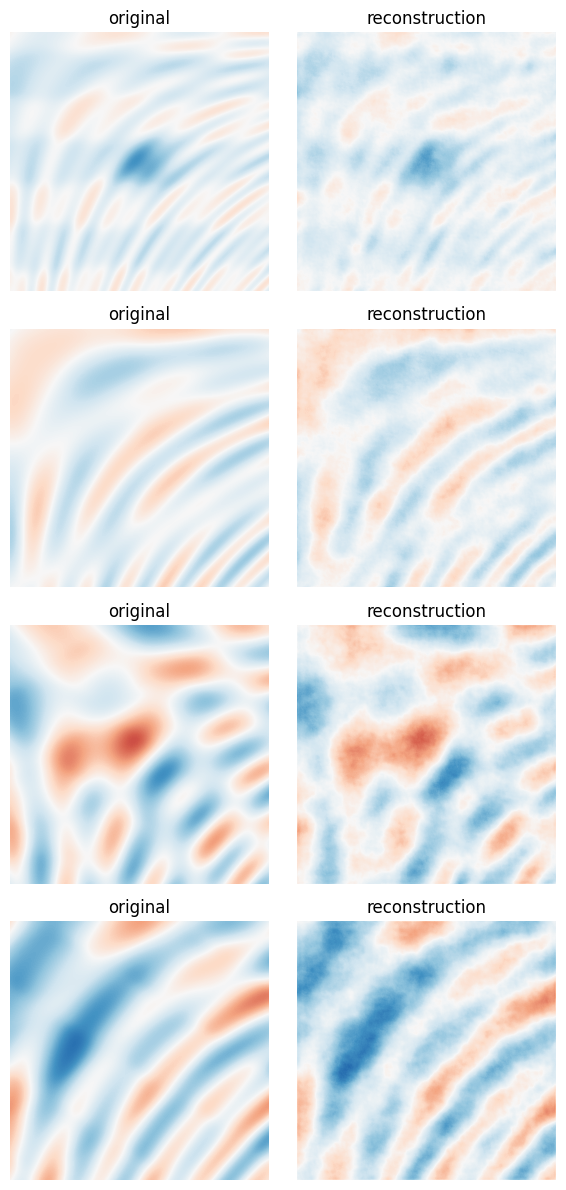

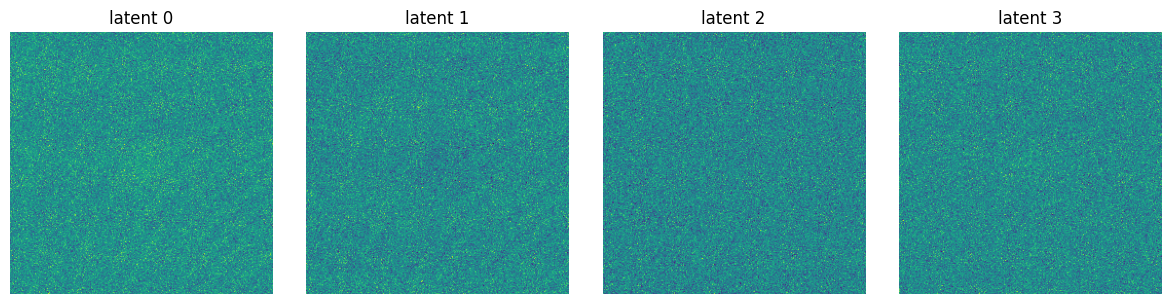

In [ ]:
# ------------------
# Plot originals and reconstructions
# ------------------
n = orig.shape[0]
fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))
for i in range(n):
    axes[i,0].imshow(orig[i,0], cmap="RdBu_r", vmin=-1, vmax=1)
    axes[i,0].set_title("original")
    axes[i,0].axis("off")
    axes[i,1].imshow(recon[i,0], cmap="RdBu_r", vmin=-1, vmax=1)
    axes[i,1].set_title("reconstruction")
    axes[i,1].axis("off")
plt.tight_layout()
plt.show()

# ------------------
# Optional: visualize latent channels
# ------------------
fig, axes = plt.subplots(1, min(4, z.shape[1]), figsize=(12,3))
for i in range(min(4, z.shape[1])):
    axes[i].imshow(z[0,i], cmap="viridis")
    axes[i].set_title(f"latent {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
vae

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(8, 64, eps=1e-06, affine=True)
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(8, 64, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(8, 64, eps=1e-06, affine=True)
            (conv1): Conv2d(64, 1

Using device: cuda
Loading data...
Original data shape: (1000, 1024, 1024)
Input batch shape: torch.Size([4, 1, 1024, 1024])

Testing: stability_mse (stabilityai/sd-vae-ft-mse)
Loading stabilityai/sd-vae-ft-mse...


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Using input size: torch.Size([4, 1, 512, 512])
Latent shape: torch.Size([4, 4, 64, 64])


/tmp/ipykernel_662931/910558458.py:170: UserWarning: Using a target size (torch.Size([4, 3, 1024, 1024])) that is different to the input size (torch.Size([4, 1, 1024, 1024])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mse_error = F.mse_loss(batch_1024, recon_1024)


...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/9.79M [00:00<?, ?B/s]

❌ Failed: 'EncoderTiny' object has no attribute 'conv_in'

Testing: sdxl_vae (stabilityai/sdxl-vae)
Loading stabilityai/sdxl-vae...


config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Using input size: torch.Size([4, 1, 1024, 1024])
Latent shape: torch.Size([4, 4, 128, 128])
✅ Success! MSE Error: 0.010166

CREATING VISUALIZATIONS


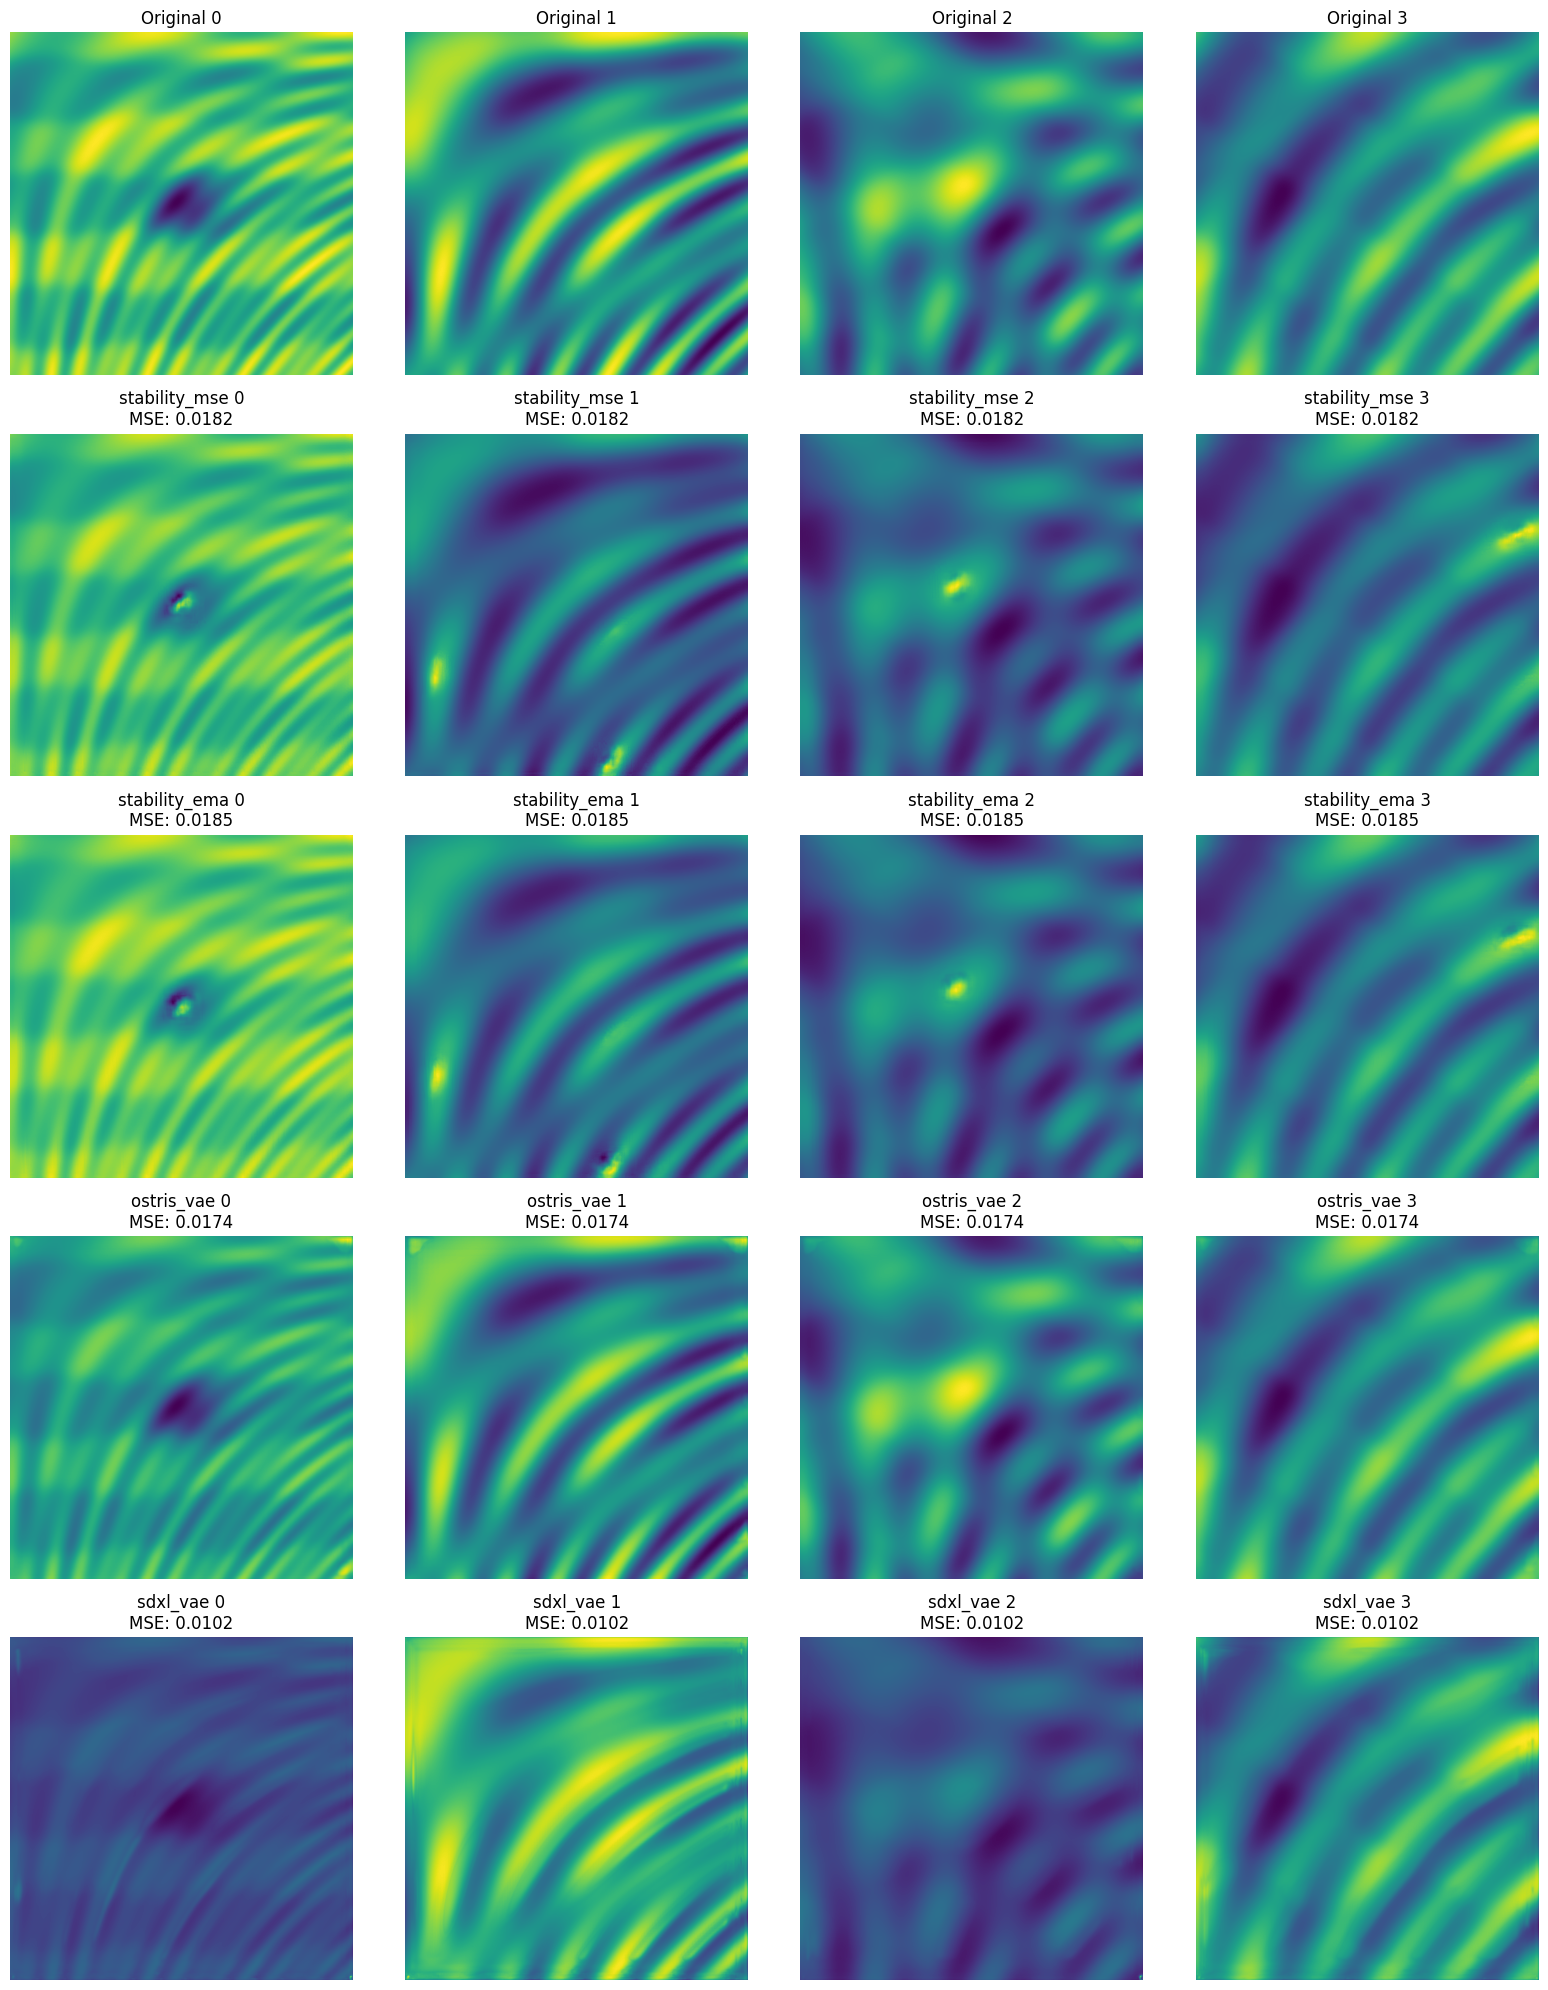


SUMMARY
✅ Successful VAEs:
  stability_mse: MSE = 0.018240 (stabilityai/sd-vae-ft-mse)
  stability_ema: MSE = 0.018468 (stabilityai/sd-vae-ft-ema)
  ostris_vae: MSE = 0.017392 (ostris/vae-kl-f8-d16)
  sdxl_vae: MSE = 0.010166 (stabilityai/sdxl-vae)

❌ Failed VAEs:
  tiny_vae: 'EncoderTiny' object has no attribute 'conv_in'

🏆 Best performing VAE: sdxl_vae (MSE: 0.010166)
   Model path: stabilityai/sdxl-vae

📋 Code to use the best VAE:

# Load the best performing VAE for your use case:
from diffusers import AutoencoderKL
vae = load_and_modify_vae("stabilityai/sdxl-vae", device)

# Use it for inference:
with torch.no_grad():
    batch_resized = resize_for_vae(your_batch, 512)  # or 1024 for SDXL
    encode_out = vae.encode(batch_resized)
    z = encode_out.latent_dist.sample() * vae.config.scaling_factor
    recon = vae.decode(z / vae.config.scaling_factor).sample



'\nIf the above doesn\'t work well, here are some other options:\n\n1. Medical Imaging Models (may need different loading):\n   - "microsoft/DiT-XL-2-256" (though this is for generation)\n   - Look for models tagged with "medical", "grayscale", "single-channel"\n\n2. Convert RGB pretrained to grayscale:\n   - The approach above should work with most VAEs\n   - "stabilityai/sd-vae-ft-mse" is often the most robust\n\n3. Domain-specific models:\n   - Search HuggingFace for models in your specific domain\n   - Look for "autoencoder", "vae", "latent" tags\n\n4. Train your own:\n   - Use the architecture from successful models above\n   - Fine-tune on your specific data\n\nThe code above tests multiple pretrained options and shows you \nwhich works best for your specific 1024x1024 single-channel data.\n'

In [ ]:
import torch
import matplotlib.pyplot as plt
from diffusers import AutoencoderKL
import numpy as np
import torch.nn.functional as F

# ===================================================================
# AVAILABLE PRETRAINED SINGLE-CHANNEL OPTIONS ON HUGGING FACE
# ===================================================================

# Option 1: Tiny AutoEncoder (can be modified for single channel)
from diffusers import AutoencoderTiny

# Option 2: Custom models that might work with modification
PRETRAINED_VAES = {
    "stability_mse": "stabilityai/sd-vae-ft-mse",
    "stability_ema": "stabilityai/sd-vae-ft-ema", 
    "ostris_vae": "ostris/vae-kl-f8-d16",  # Alternative VAE
    "tiny_vae": "madebyollin/taesd",  # Tiny AutoEncoder
    "sdxl_vae": "stabilityai/sdxl-vae",
}

def load_and_modify_vae(model_name, device):
    """
    Load a pretrained VAE and modify it for single-channel input
    """
    print(f"Loading {model_name}...")
    
    if "taesd" in model_name or "tiny" in model_name.lower():
        # Special handling for Tiny AutoEncoder
        try:
            vae = AutoencoderTiny.from_pretrained(model_name)
        except:
            print(f"Failed to load {model_name} as AutoencoderTiny, trying AutoencoderKL...")
            vae = AutoencoderKL.from_pretrained(model_name)
    else:
        vae = AutoencoderKL.from_pretrained(model_name)
    
    # Modify the first convolution layer for single channel input
    original_conv = vae.encoder.conv_in
    
    # Create new conv layer with 1 input channel
    new_conv = torch.nn.Conv2d(
        in_channels=1,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=original_conv.bias is not None
    )
    
    # Initialize by averaging RGB weights to grayscale
    with torch.no_grad():
        new_conv.weight = torch.nn.Parameter(
            original_conv.weight.mean(dim=1, keepdim=True)
        )
        if original_conv.bias is not None:
            new_conv.bias = torch.nn.Parameter(original_conv.bias.clone())
    
    # Replace the conv layer
    vae.encoder.conv_in = new_conv
    vae.eval()
    vae.to(device)
    
    return vae

def resize_for_vae(batch, target_size):
    """
    Resize batch to target size for VAE compatibility
    """
    if batch.shape[-1] != target_size:
        batch = F.interpolate(
            batch, 
            size=(target_size, target_size), 
            mode='bilinear', 
            align_corners=False
        )
    return batch

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load your data
    print("Loading data...")
    data = np.load("../data/non_linear_eq/train_high_resolution_solutions.npy")
    print(f"Original data shape: {data.shape}")
    
    # Normalize to [-1, 1]
    data_min, data_max = data.min(), data.max()
    data = (data - data_min) / (data_max - data_min)
    data = data * 2.0 - 1.0
    
    # Ensure proper shape (N, 1, H, W)
    if len(data.shape) == 3:
        data = data[:, np.newaxis, :, :]
    
    batch_1024 = torch.tensor(data[:4]).float().to(device)
    print(f"Input batch shape: {batch_1024.shape}")
    
    # Test different pretrained VAEs
    results = {}
    
    for vae_name, model_path in PRETRAINED_VAES.items():
        print(f"\n{'='*50}")
        print(f"Testing: {vae_name} ({model_path})")
        print('='*50)
        
        try:
            # Load and modify VAE
            vae = load_and_modify_vae(model_path, device)
            
            # Determine best input size for this VAE
            if "tiny" in vae_name.lower() or "taesd" in model_path:
                input_size = 512  # Tiny AE works better with 512
            elif "sdxl" in vae_name.lower():
                input_size = 1024  # SDXL can handle larger
            else:
                input_size = 512  # Standard SD VAEs prefer 512
            
            # Resize input if needed
            batch_resized = resize_for_vae(batch_1024, input_size)
            print(f"Using input size: {batch_resized.shape}")
            
            with torch.no_grad():
                # Encode
                encode_out = vae.encode(batch_resized)
                
                # Handle different VAE types
                if hasattr(encode_out, 'latent_dist'):
                    # Standard AutoencoderKL
                    latent_dist = encode_out.latent_dist
                    z = latent_dist.sample()
                    if hasattr(vae.config, 'scaling_factor'):
                        z = z * vae.config.scaling_factor
                elif hasattr(encode_out, 'latents'):
                    # Some VAEs return latents directly
                    z = encode_out.latents
                else:
                    # Direct tensor output
                    z = encode_out
                
                print(f"Latent shape: {z.shape}")
                
                # Decode
                if hasattr(vae.config, 'scaling_factor') and hasattr(encode_out, 'latent_dist'):
                    z_scaled = z / vae.config.scaling_factor
                    decode_out = vae.decode(z_scaled)
                else:
                    decode_out = vae.decode(z)
                
                # Handle different decode output types
                if hasattr(decode_out, 'sample'):
                    recon = decode_out.sample
                else:
                    recon = decode_out
                
                # Resize back to 1024 if needed
                if recon.shape[-1] != 1024:
                    recon_1024 = F.interpolate(
                        recon, 
                        size=(1024, 1024), 
                        mode='bilinear', 
                        align_corners=False
                    )
                else:
                    recon_1024 = recon
                
                # Calculate reconstruction error
                mse_error = F.mse_loss(batch_1024, recon_1024)
                
                # Store results
                results[vae_name] = {
                    'reconstruction': recon_1024.cpu(),
                    'latents': z.cpu(),
                    'mse_error': mse_error.item(),
                    'model_path': model_path,
                    'success': True
                }
                
                print(f"✅ Success! MSE Error: {mse_error:.6f}")
                
        except Exception as e:
            print(f"❌ Failed: {str(e)}")
            results[vae_name] = {
                'success': False,
                'error': str(e),
                'model_path': model_path
            }
    
    # ===== VISUALIZATION =====
    print(f"\n{'='*50}")
    print("CREATING VISUALIZATIONS")
    print('='*50)
    
    successful_results = {k: v for k, v in results.items() if v['success']}
    
    if not successful_results:
        print("❌ No VAEs worked successfully!")
        return
    
    n_models = len(successful_results)
    fig, axes = plt.subplots(n_models + 1, 4, figsize=(16, 4 * (n_models + 1)))
    
    if n_models == 0:
        axes = axes.reshape(1, -1)
    
    # Plot original images
    for i in range(4):
        if n_models > 0:
            axes[0, i].imshow(batch_1024[i, 0].cpu().numpy(), cmap='viridis')
            axes[0, i].set_title(f'Original {i}')
            axes[0, i].axis('off')
        else:
            axes[i].imshow(batch_1024[i, 0].cpu().numpy(), cmap='viridis')
            axes[i].set_title(f'Original {i}')
            axes[i].axis('off')
    
    # Plot reconstructions
    for row, (vae_name, result) in enumerate(successful_results.items()):
        for i in range(4):
            if n_models > 0:
                axes[row + 1, i].imshow(result['reconstruction'][i, 0].numpy(), cmap='viridis')
                axes[row + 1, i].set_title(f'{vae_name} {i}\nMSE: {result["mse_error"]:.4f}')
                axes[row + 1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # ===== SUMMARY =====
    print(f"\n{'='*50}")
    print("SUMMARY")
    print('='*50)
    
    print("✅ Successful VAEs:")
    for vae_name, result in successful_results.items():
        print(f"  {vae_name}: MSE = {result['mse_error']:.6f} ({result['model_path']})")
    
    print("\n❌ Failed VAEs:")
    for vae_name, result in results.items():
        if not result['success']:
            print(f"  {vae_name}: {result['error']}")
    
    if successful_results:
        best_vae = min(successful_results.items(), key=lambda x: x[1]['mse_error'])
        print(f"\n🏆 Best performing VAE: {best_vae[0]} (MSE: {best_vae[1]['mse_error']:.6f})")
        print(f"   Model path: {best_vae[1]['model_path']}")
        
        # Save best reconstruction code
        print(f"\n📋 Code to use the best VAE:")
        print(f"""
# Load the best performing VAE for your use case:
from diffusers import AutoencoderKL
vae = load_and_modify_vae("{best_vae[1]['model_path']}", device)

# Use it for inference:
with torch.no_grad():
    batch_resized = resize_for_vae(your_batch, 512)  # or 1024 for SDXL
    encode_out = vae.encode(batch_resized)
    z = encode_out.latent_dist.sample() * vae.config.scaling_factor
    recon = vae.decode(z / vae.config.scaling_factor).sample
""")

# if __name__ == "__main__":
main()

# ===================================================================
# ALTERNATIVE: BEST SINGLE-CHANNEL MODELS TO TRY
# ===================================================================
"""
If the above doesn't work well, here are some other options:

1. Medical Imaging Models (may need different loading):
   - "microsoft/DiT-XL-2-256" (though this is for generation)
   - Look for models tagged with "medical", "grayscale", "single-channel"

2. Convert RGB pretrained to grayscale:
   - The approach above should work with most VAEs
   - "stabilityai/sd-vae-ft-mse" is often the most robust

3. Domain-specific models:
   - Search HuggingFace for models in your specific domain
   - Look for "autoencoder", "vae", "latent" tags

4. Train your own:
   - Use the architecture from successful models above
   - Fine-tune on your specific data

The code above tests multiple pretrained options and shows you 
which works best for your specific 1024x1024 single-channel data.
"""

# Aeronef

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from cetaceo.evaluators import RegressionEvaluator

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x786a53d69050>>
Traceback (most recent call last):
  File "/home/d.ramos/.conda/envs/cetaceo/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [2]:
results_dir = "../results/aeronef/mask_no_scaled" # mask_no_scaled_self_condition, no_mask_on_channel
data_dir = "../data/aeronef"

In [3]:
train_samples = np.load(f"{data_dir}/dataset_train.npy")
train_min, train_max = train_samples[:, 0, ...].min(), train_samples[:, 0, ...].max()
true_values = np.load(f"{data_dir}/dataset_test.npy")
true_values[:, 0, ...] = (true_values[:, 0, ...] - train_min) / (train_max - train_min)
paramters = np.load(f"{data_dir}/flight_conditions_test.npy")
true_values.shape

(202, 2, 128, 256)

In [4]:
height, width = 128, 256
predictions = torch.load(f"{results_dir}/test_predictions_ema_150000.pt", weights_only=True)
predictions = predictions.view(-1, 2, height, width)
# predictions = predictions * (train_max - train_min) + train_min
predictions.shape

torch.Size([202, 2, 128, 256])

In [5]:
def evaluate_2_channels(preds, true_values):
    evaluator = RegressionEvaluator()
    true_values_masked = true_values[:, 0, :, :][true_values[:, 1, :, :] == 1]
    predictions_masked = preds[:, 0, :, :][true_values[:, 1, :, :] == 1]
    metrics = evaluator(true_values_masked, predictions_masked)
    evaluator.print_metrics()
    return metrics

true_values[:, 0, :, :][true_values[:, 1, :, :] == 0].sum()

544249.9490072549

In [6]:
eval_metrics = evaluate_2_channels(predictions, true_values)


Regression evaluator metrics:
mse: 1.0202e-04
rmse: 0.0101
mae: 0.0019
mre: 0.4879%
ae_95: 0.0059
ae_99: 0.0245
r2: 0.9860
l2_error: 0.0188


In [7]:
def plot_images_grid(images, input_parameters, mask=None):
    fig, axes = plt.subplots(int(np.sqrt(len(images))), int(np.sqrt(len(images))), figsize=(12,12))
    for i, ax in enumerate(axes.flat):
        image = images[i, 0].squeeze()#.clone()
        mean_value = image.mean()
        image[mask == 0] = mean_value
        im = ax.imshow(image, cmap='RdBu_r')
        ax.set_title(f"Vel={input_parameters[i][0].item():.2f}, Alpha={input_parameters[i][1].item():.2f}")
        plt.colorbar(im, ax=ax)
        ax.axis('off')
    plt.show()

In [8]:
evaluate_2_channels(predictions[2:3], true_values[2:3])


Regression evaluator metrics:
mse: 8.8095e-08
rmse: 2.9681e-04
mae: 2.6376e-04
mre: 0.0476%
ae_95: 4.8320e-04
ae_99: 6.1036e-04
r2: 0.6389
l2_error: 5.3577e-04


{'mse': 8.809450078706543e-08,
 'rmse': 0.0002968071777889905,
 'mae': 0.00026375591810741004,
 'mre': 0.04762044535048219,
 'ae_95': 0.00048319513575374994,
 'ae_99': 0.0006103556360147867,
 'r2': 0.6389076335800916,
 'l2_error': 0.0005357695169006946}

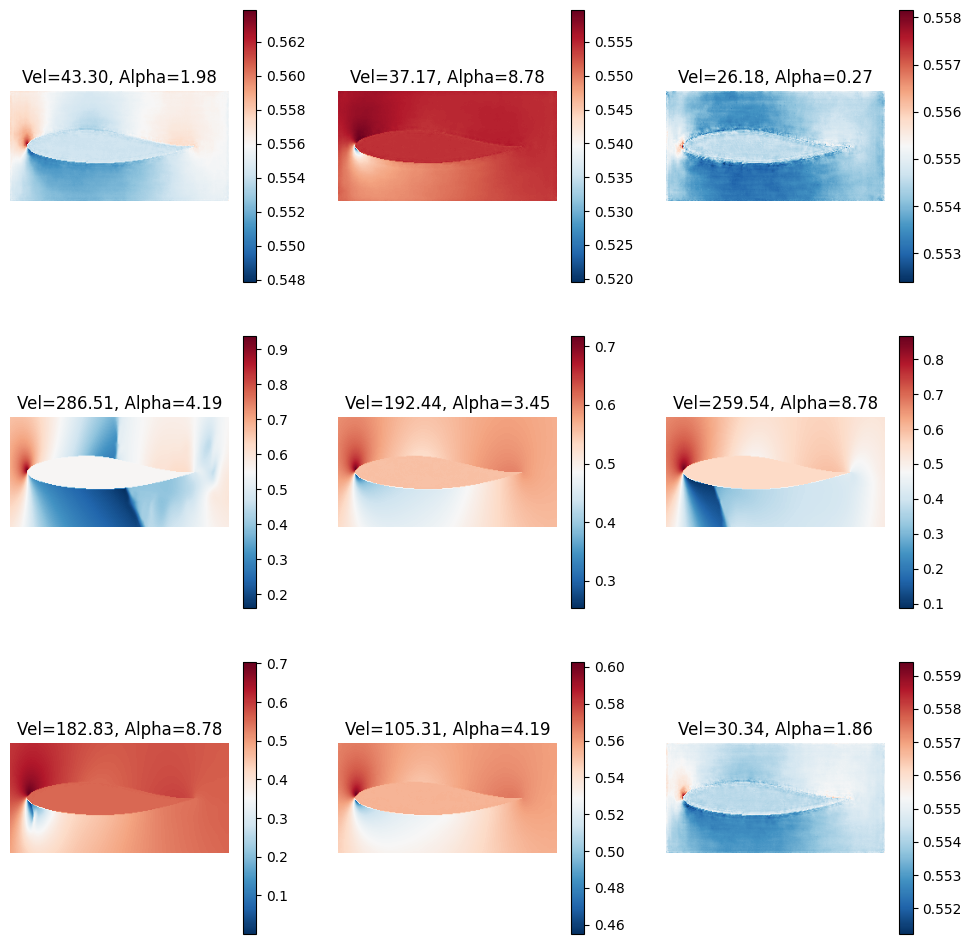

In [9]:
plot_images_grid(predictions[:9], paramters[:9])

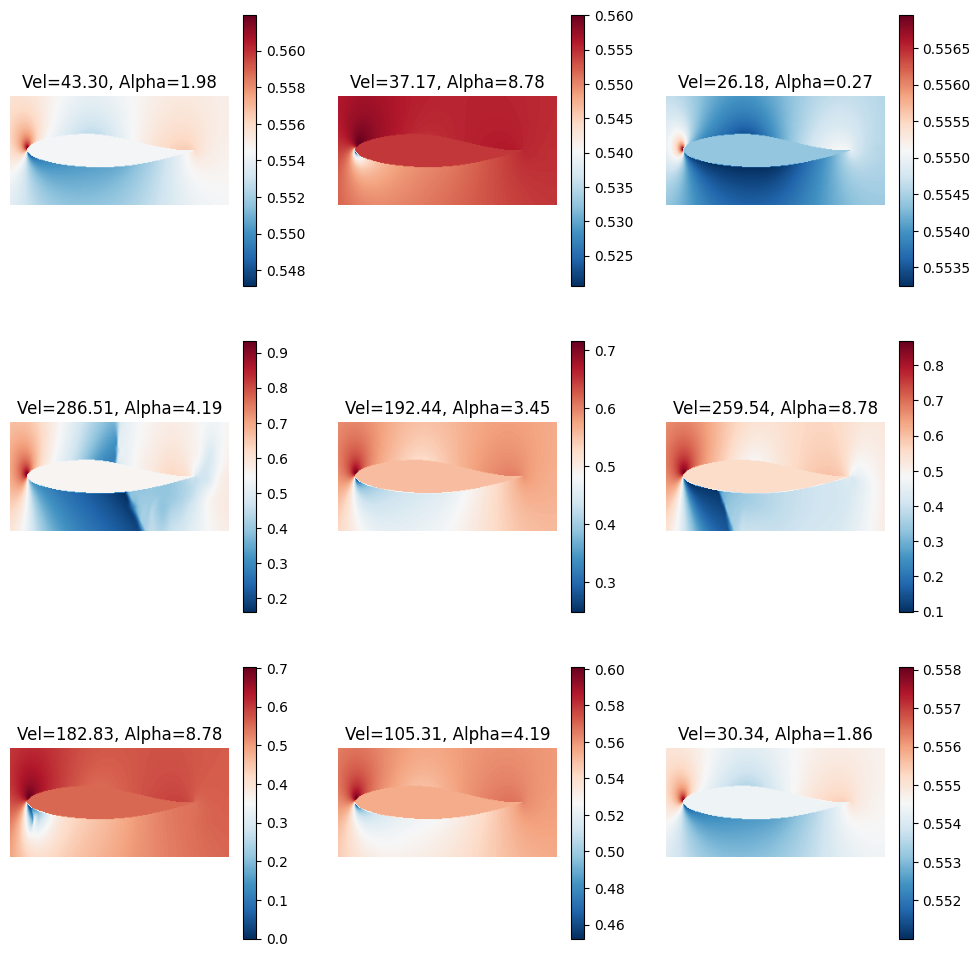

In [10]:
plot_images_grid(true_values[:9], paramters[:9])

In [ ]:
plot_images_grid(100*torch.abs(predictions[:9] - true_values[:9])/(true_values[:9]+1e-5), paramters[:9])

## Predictions without mask

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from cetaceo.evaluators import RegressionEvaluator

In [ ]:
results_dir = "../results/aeronef/no_mask_XL_02_drop_prob_500_timesteps_adaln" # mask_no_scaled_self_condition, no_mask_on_channel
data_dir = "../data/aeronef"

# "../results/aeronef/no_mask_big_adaLNZero_lr_schedule_150k/test_predictions_ema_150000.pt",
# "../results/aeronef/no_mask_big_lr_schedule_150k/test_predictions_ema_150000.pt"

In [ ]:
train_samples = np.load(f"{data_dir}/no_mask_dataset_train.npy")
train_min, train_max = train_samples[:, 0, ...].min(), train_samples[:, 0, ...].max()
train_mean, train_std = train_samples[:, 0, ...].mean(), train_samples[:, 0, ...].std()
true_values = np.load(f"{data_dir}/no_mask_dataset_test.npy")
# true_values = (true_values - train_mean) / train_std
# true_values = true_values.squeeze()
paramters = np.load(f"{data_dir}/flight_conditions_test.npy")
true_values.shape

(202, 1, 128, 256)

In [ ]:
train_samples_with_mask = np.load(f"{data_dir}/dataset_test.npy")
mask = train_samples_with_mask[:, 1:, ...]
mask.shape

(202, 1, 128, 256)

In [ ]:
height, width = 128, 256
predictions = torch.load(f"{results_dir}/test_predictions_ema_200000.pt", weights_only=True)#.squeeze()
# predictions = predictions.view(-1, 2, height, width)
predictions = predictions * (train_max - train_min) + train_min
# predictions = (predictions - train_mean) / train_std
predictions.shape

torch.Size([202, 1, 128, 256])

In [ ]:
evaluator = RegressionEvaluator()
metrics = evaluator(predictions, true_values)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 2.3269e+06
rmse: 1.5254e+03
mae: 327.4147
mre: 106190.4512%
ae_95: 817.9932
ae_99: 4.5583e+03
r2: 0.9850
l2_error: 0.1163


In [ ]:
preds_masked = predictions[mask == 1]
true_values_masked = true_values[mask == 1]
evaluator = RegressionEvaluator()
metrics = evaluator(preds_masked, true_values_masked)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 2.3162e+06
rmse: 1.5219e+03
mae: 319.1218
mre: 112876.3962%
ae_95: 783.7570
ae_99: 4.2928e+03
r2: 0.9844
l2_error: 0.1207


In [ ]:
plot_images_grid(predictions[:9], paramters[:9], mask=mask[0, 0])

In [ ]:
plot_images_grid(true_values[:9], paramters[:9], mask=mask[0, 0])

In [ ]:
predictions_files = [
    # "../results/aeronef/mask_no_scaled_small_airfoil/test_predictions_ema_150000_cfg_1.pt",
    # "../results/aeronef/mask_no_scaled_small_airfoil/test_predictions_ema_150000_cfg_2.pt",
    # "../results/aeronef/mask_no_scaled_small_airfoil/test_predictions_ema_150000.pt",
    # "../results/aeronef/mask_no_scaled_small_airfoil/test_predictions_ema_150000_cfg_8.pt",
    # "../results/aeronef/mask_no_scaled_small_airfoil/test_predictions_ema_150000_cfg_plus_plus.pt",
    "../results/aeronef/no_mask_big_adaLNZero_lr_schedule_150k/test_predictions_ema_150000.pt",
    "../results/aeronef/no_mask_big_lr_schedule_150k/test_predictions_ema_150000.pt",
    "../results/aeronef/no_mask_big_lr_schedule_02_drop_prob/test_predictions_ema_150000.pt",
    "../results/aeronef/no_mask_big_lr_schedule_500_timesteps/test_predictions_ema_150000.pt",
    "../results/aeronef/no_mask_big_adaLNZero_lr_schedule_150k/test_predictions_ema_300000.pt",
    "../results/aeronef/no_mask_big_02_drop_prob_500_timesteps_adaln/test_predictions_ema_200000.pt",
    "../results/aeronef/no_mask_XL_02_drop_prob_500_timesteps_adaln/test_predictions_ema_200000.pt"
    
    
]

In [ ]:
def eval_model(model_path):
    print(f"\nEvaluating model: {model_path}")
    predictions = torch.load(model_path, weights_only=True)
    predictions = predictions * (train_max - train_min) + train_min
    # evaluator = RegressionEvaluator()
    # metrics = evaluator(predictions, true_values)
    # print("Overall metrics:")
    # evaluator.print_metrics()
    preds_masked = predictions[mask == 1]
    true_values_masked = true_values[mask == 1]
    evaluator_masked = RegressionEvaluator()
    metrics_masked = evaluator_masked(preds_masked, true_values_masked)
    print("Masked metrics:")
    # evaluator_masked.print_metrics()
    return metrics_masked

all_metrics = []
for model_file in predictions_files:
    metrics = eval_model(model_file)
    all_metrics.append(metrics)


Evaluating model: ../results/aeronef/no_mask_big_adaLNZero_lr_schedule_150k/test_predictions_ema_150000.pt
Masked metrics:

Evaluating model: ../results/aeronef/no_mask_big_lr_schedule_150k/test_predictions_ema_150000.pt
Masked metrics:

Evaluating model: ../results/aeronef/no_mask_big_lr_schedule_02_drop_prob/test_predictions_ema_150000.pt
Masked metrics:

Evaluating model: ../results/aeronef/no_mask_big_lr_schedule_500_timesteps/test_predictions_ema_150000.pt
Masked metrics:

Evaluating model: ../results/aeronef/no_mask_big_adaLNZero_lr_schedule_150k/test_predictions_ema_300000.pt
Masked metrics:

Evaluating model: ../results/aeronef/no_mask_big_02_drop_prob_500_timesteps_adaln/test_predictions_ema_200000.pt
Masked metrics:


In [ ]:
import pandas as pd

df_results = pd.DataFrame(all_metrics)
df_results = df_results.sort_values(by="mse", ascending=True)
df_results["model_name"] = [model_file.split("/")[-2] for model_file in predictions_files]
df_results

,mse,rmse,mae,mre,ae_95,ae_99,r2,l2_error,model_name
2,4.816624e+05,694.019010,204.031320,61682.199107,622.112879,1999.069200,0.996759,0.055039,no_mask_big_adaLNZero_lr_schedule_150k
3,5.778306e+05,760.151671,208.699568,64440.086647,628.756618,1835.231159,0.996105,0.060283,no_mask_big_lr_schedule_150k
0,6.187839e+05,786.628201,229.544095,79891.648647,676.719140,1760.118993,0.995832,0.062383,no_mask_big_lr_schedule_02_drop_prob
1,7.407634e+05,860.676157,233.017149,62077.191289,697.009837,2024.740229,0.994994,0.068255,no_mask_big_lr_schedule_500_timesteps
5,8.013503e+05,895.181715,219.393848,64834.638496,631.110093,2014.378972,0.994545,0.070992,no_mask_big_adaLNZero_lr_schedule_150k
4,1.146435e+06,1070.716982,265.603853,139659.408664,778.786292,2301.974151,0.992212,0.084913,no_mask_big_02_drop_prob_500_timesteps_adaln


# Aeronef CP

In [1]:
import numpy as np
import torch

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
np.random.seed(42)

def get_split_indices(split_name, split_data, all_conds, atol=1e-4, rtol=1e-12):
    data = split_data[split_name]
    indices = []

    for row in data:
        # Compare this row against all rows in all_conds
        matches = np.all(np.isclose(all_conds, row, atol=atol, rtol=rtol), axis=1)
        found = np.where(matches)[0]

        if len(found) == 0:
            raise KeyError(f"No match found within tolerance for {row}")
        if len(found) > 1:
            raise ValueError(f"Multiple matches found within tolerance for {row}")

        indices.append(found[0])

    return indices

data = np.load("../data/aeronef/db_random.npy", allow_pickle=True).item()
cp = data["Cp"]
alpha, vel_inf = data["Alpha"], data["Vinf"]
all_conds = np.stack((alpha, vel_inf), axis=1)
split_data = np.load("../data/aeronef/best_train-val-test_split.npy", allow_pickle=True).item()
training_indices = get_split_indices("Train", split_data, all_conds)
val_indices = get_split_indices("Validation", split_data, all_conds)
test_indices = get_split_indices("Test", split_data, all_conds)
# train_size = 0.8
# training_indices = np.random.choice(cp.shape[0], int(cp.shape[0] * train_size), replace=False)
# test_indices = np.setdiff1d(np.arange(cp.shape[0]), training_indices)
cp_train = cp[training_indices]
cp_val = cp[val_indices]
cp_test = cp[test_indices]
alpha_test, vel_test = data["Alpha"][test_indices], data["Vinf"][test_indices]
parameters = np.stack((alpha_test, vel_test), axis=1)
cp_min, cp_max = cp_train.min(), cp_train.max()
cp_mean, cp_std = cp_train.mean(), cp_train.std()
cp_test.shape, parameters.shape

((152, 691), (152, 2))

In [2]:
# np.save("parameters_test.npy", parameters)
# np.save("cp_test.npy", cp_test)

In [3]:
from cetaceo.evaluators import RegressionEvaluator
preds = torch.load("../results/aeronef_cp_good_split/unet_M/test_predictions_ema_cfg2.pt", weights_only=True, map_location="cpu").squeeze()
# preds = preds * (cp_max - cp_min) + cp_min
preds = (preds * cp_std) + cp_mean

evaluator = RegressionEvaluator()
# metrics = evaluator(preds, cp_val)
metrics = evaluator(preds, cp_test) # cp_test
evaluator.print_metrics()


Regression evaluator metrics:
mse: 9.2349e-05
rmse: 0.0096
mae: 0.0024
mre: 3.2088%
ae_95: 0.0076
ae_99: 0.0318
r2: 0.9998
l2_error: 0.0132


In [4]:
# cp_test = np.load("/home/airbus/CETACEO_cp_interp/CLUSTERING_AERO-NEF/results_diffusion_unet/cp_test.npy")
# preds = np.load("/home/airbus/CETACEO_cp_interp/CLUSTERING_AERO-NEF/results_diffusion_unet/diffusion_preds.npy")
# metrics = evaluator(preds, cp_test) # cp_test
# evaluator.print_metrics()

In [5]:
# np.save("/home/airbus/CETACEO_cp_interp/CLUSTERING_AERO-NEF/results_diffusion_unet/diffusion_preds_unet_M_cfg2.npy", preds.numpy())

In [6]:
# # preds = torch.load("../results/aeronef_cp_new_split/testing_FM/sample-4.pt", weights_only=True, map_location="cpu").squeeze()
# # preds = preds * (cp_max - cp_min) + cp_min
# # evaluator = RegressionEvaluator()
# # metrics = evaluator(preds, cp_val)
# # evaluator.print_metrics()
# fig, axes = plt.subplots(4, 5, figsize=(20, 16))
# axes = axes.flatten()  # Flatten to make indexing easier
# x = data["Airfoil"][:, 0]

# for airfoil_idx in range(20):
#     ax = axes[airfoil_idx]
#     # airfoil_idx += 19
    
#     # Get data for current airfoil
#     cp_pred = preds[airfoil_idx].flatten()
#     cp_true = cp_test[airfoil_idx].flatten()
#     # cp_true = cp_val[airfoil_idx].flatten()
#     conditions = parameters[airfoil_idx]
#     # Plot on current subplot
#     ax.scatter(x, cp_true, label="true cp", c='blue', s=1)
#     ax.scatter(x, cp_pred, label="predicted cp", c='orange', s=1)
#     ax.set_title(f"Airfoil {airfoil_idx}: α={conditions[0]:.2f}°, VelInf={conditions[1]:.2f}")
#     ax.legend(fontsize=8)
#     ax.grid(True, alpha=0.3)
#     ax.set_xlabel('x')
#     ax.set_ylabel('cp')

# plt.tight_layout()
# plt.show()

ahora con todos los que hay en `results/aeronef_cp/`

In [7]:
import os
import pandas as pd
from cetaceo.evaluators import RegressionEvaluator
# from pyLOM.NN import MLP, RegressionEvaluator

In [8]:
def eval_preds(path, true_values):
    preds = torch.load(path, weights_only=True, map_location="cpu").squeeze()
    preds = preds[:, :691]
    if "norm_coefficients.json" in os.listdir(os.path.join(*path.split("/")[:-1])):
        import json
        coeffs = json.load(open(os.path.join(*path.split("/")[:-1], "norm_coefficients.json")))
        if "cp_mean" in coeffs:
            preds = (preds * coeffs["cp_std"]) + coeffs["cp_mean"]
        elif "cp_min" in coeffs and "cp_max" in coeffs:
            if "feature_range" in coeffs:
                preds = (preds - coeffs["feature_range"][0]) / (coeffs["feature_range"][1] - coeffs["feature_range"][0])
            preds = preds * (coeffs["cp_max"] - coeffs["cp_min"]) + coeffs["cp_min"]
        else:
            raise ValueError("Unknown normalization coefficients in norm_coefficients.json")
    elif "standard_scale" in path:
        preds = (preds * cp_std) + cp_mean
    else:
        preds = preds * (cp_max - cp_min) + cp_min
    evaluator = RegressionEvaluator()
    metrics = evaluator(preds, true_values)
    # print(f"Evaluating {os.path.basename(path)}:")
    # evaluator.print_metrics()
    return metrics

def eval_foder(base_dir, test_data=True):
    all_metrics = []
    for model_name in os.listdir(base_dir):
        # get the name of the last sample in the folder
        files = list(filter(lambda x: x.startswith("sample-") and x.endswith(".pt"), os.listdir(base_dir + model_name)))
        if test_data:
            if "test_predictions_ema.pt" not in os.listdir(os.path.join(base_dir, model_name)):
                print(f"Model {model_name} has not finished training. Can't be evaluated for test data yet.")
                continue
            metrics = eval_preds(os.path.join(base_dir, model_name, "test_predictions_ema.pt"), cp_test)
        else:
            if len(files) != 0:
                last_sample_name = files[-1]
                try:
                    metrics = eval_preds(os.path.join(base_dir, model_name, last_sample_name), cp_val)
                    metrics["sample_file"] = last_sample_name
                except:
                    print(f"{model_name} ha fallado")
                
        metrics["model_name"] = model_name
        all_metrics.append(metrics)
    return all_metrics

In [9]:
all_metrics = eval_foder("../results/aeronef_cp_good_split/", test_data=True)
df_results = pd.DataFrame(all_metrics)
df_results = df_results.sort_values(by="mae", ascending=True)
df_results

Model dit_s_fsdp_test has not finished training. Can't be evaluated for test data yet.
Model dit_xxs_mlp_2.5 has not finished training. Can't be evaluated for test data yet.


,mse,rmse,mae,mre,ae_95,ae_99,r2,l2_error,model_name
29,0.000094,0.009700,0.002344,2.864703,0.006956,0.032949,0.999804,0.013367,unet_M_attn_correct
26,0.000090,0.009485,0.002454,3.026744,0.007331,0.033757,0.999812,0.013072,unet_M_padding_before
28,0.000104,0.010222,0.002514,3.277616,0.007869,0.033444,0.999782,0.014087,dit_xxs_coord_pe
19,0.000106,0.010315,0.002523,3.309600,0.008569,0.034343,0.999778,0.014215,dit_xxs_mlp_2.5_drop_prob_0.1
21,0.000076,0.008744,0.002528,3.207131,0.007810,0.028555,0.999840,0.012050,dit_2_xxs_mlp_2.5
24,0.000083,0.009110,0.002549,3.010368,0.007641,0.032738,0.999827,0.012554,dit_4_xxs_mlp_2.5
27,0.000093,0.009643,0.002596,3.174183,0.007963,0.032368,0.999806,0.013289,dit_xxs_rope
23,0.000080,0.008966,0.002634,3.630999,0.007998,0.029431,0.999832,0.012356,dit_2_xxs_mlp_2.5_v2
25,0.000084,0.009139,0.002688,3.417238,0.008443,0.032115,0.999826,0.012595,dit_8_xxs_mlp_2.5
22,0.000127,0.011261,0.002798,3.424797,0.008330,0.035037,0.999735,0.015518,dit_1_xxs_mlp_2.5_with_pad


In [10]:
import matplotlib.pyplot as plt
import re 

def metric_evlolution_plot(folder, metric="mse", skip_models=["unet_learn_sigma", "baseline"], regular_expression_filter=None):
    plt.figure(figsize=(12, 8))
    for model_name in filter(lambda x: x not in skip_models and (regular_expression_filter is None or re.match(regular_expression_filter, x)), os.listdir(folder)):
        files = list(filter(lambda x: x.startswith("sample-") and x.endswith(".pt"), os.listdir(folder + model_name)))
        if len(files) == 0:
            continue
        all_metrics = []
        for model_file in files:
            metrics = eval_preds(os.path.join(folder, model_name, model_file), cp_val)
            all_metrics.append(metrics)
        df = pd.DataFrame(all_metrics)
        values = df[metric].values
        plt.plot(values, marker='o', linestyle='-', markersize=5, label=model_name)
        # plt.axhline(min(values), linestyle="dashed")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.yscale("log")
    plt.show()

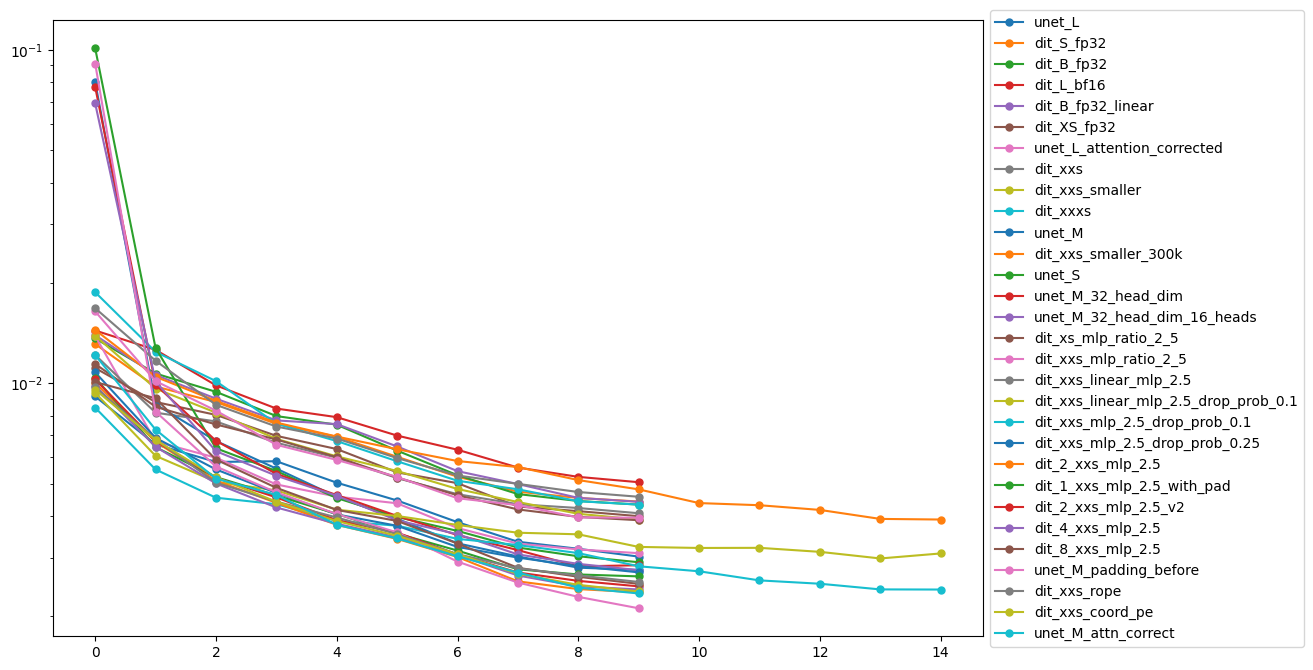

In [11]:
metric_evlolution_plot(
    "../results/aeronef_cp_good_split/",
    metric="mae",
    skip_models=["FM_dit_B_bf16", "FM_dit_B_600k_standard_scale"],
    # regular_expression_filter="FM_dit_B.*|FM_dit_XL"#"^FM(?!.*standard)"
)

In [ ]:
predictions_paths = [
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema_cfg1.pt",
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema_cfg1.5.pt",
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema_cfg2.pt",
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema_cfg2.5.pt",
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema_cfg3.pt",
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema_cfg4.pt",
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema.pt",
    # "../results/aeronef_cp_good_split/unet_M_padding_before/test_predictions_ema_cfg2.pt",
]
cfgs = [1, 1.5, 2, 2.5, 3, 4, 6]
all_metrics_cfg = []

In [18]:
predictions_paths = [
    # "../results/aeronef_cp_good_split/dit_1_xxs_mlp_2.5_with_pad/test_predictions_ema_cfg2.pt",
    "../results/aeronef_cp_good_split/dit_xxs_mlp_ratio_2_5/test_predictions_ema_cfg2.pt",
    "../results/aeronef_cp_good_split/dit_2_xxs_mlp_2.5_v2/test_predictions_ema_cfg2.pt",
    "../results/aeronef_cp_good_split/dit_2_xxs_mlp_2.5/test_predictions_ema_cfg2.pt",
    "../results/aeronef_cp_good_split/dit_4_xxs_mlp_2.5/test_predictions_ema_cfg2.pt",
    "../results/aeronef_cp_good_split/dit_8_xxs_mlp_2.5/test_predictions_ema_cfg2.pt",
]
cfgs = [1, 2, 2, 4, 8]
all_metrics_cfg = []

In [13]:
for pred, cfg in zip(predictions_paths, cfgs):
    metrics = eval_preds(pred, cp_test)
    metrics["patch size"] = cfg
    all_metrics_cfg.append(metrics)

In [14]:
df = pd.DataFrame(all_metrics_cfg)
df

,mse,rmse,mae,mre,ae_95,ae_99,r2,l2_error,patch size
0,0.000110,0.010506,0.002891,3.520699,0.009199,0.036022,0.999770,0.014479,1.0
1,0.000092,0.009601,0.002527,3.088601,0.007656,0.033948,0.999807,0.013232,1.5
2,0.000091,0.009527,0.002493,3.042985,0.007642,0.032457,0.999810,0.013130,2.0
3,0.000094,0.009714,0.002540,3.117988,0.007934,0.032099,0.999803,0.013387,2.5
4,0.000100,0.009996,0.002608,3.204659,0.008238,0.031930,0.999791,0.013776,3.0
5,0.000113,0.010610,0.002783,3.393229,0.008996,0.030643,0.999765,0.014622,4.0
6,0.000162,0.012741,0.003956,4.655549,0.013250,0.036486,0.999660,0.017559,6.0
7,0.000089,0.009423,0.002430,2.915090,0.007290,0.034741,0.999815,0.012986,2.0


# Onera

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torch.nn.functional as F

import pandas as pd

qoi_list = ['cp', 'cfx', 'cfy', 'cfz'] # names of the quantites of interest
nwallp = 260774  # number of points on the aircraft skin

data_dir = "/home/airbus/onera_data"
X_train_tot = np.load(data_dir + '/X_train.npy')
Y_train_tot = np.load(data_dir + '/Ytrain.npy')
X_test = np.load(data_dir + '/X_test.npy')
Y_test = np.load(data_dir + '/Ytest.npy')

df_description = pd.read_csv(data_dir + '/describe_train_test_repartition_with_weights.csv', index_col=0)
df_test = df_description.loc[~df_description['Train']]
df_train = df_description.loc[df_description['Train']]

confidence_weight_test = df_test['confidence_weight_simple'].values
confidence_weight_test_pointwise = np.repeat(confidence_weight_test, nwallp)

confidence_weight_train_tot = df_train['confidence_weight_simple'].values

ncase = len(df_description)  # 468
ntest = len(df_test) # 156
ntrain = ncase-ntest  # 312

# Remove the geometric informations from the input array
X_train_tot_conditions = X_train_tot[0::nwallp,6:9]
X_test_conditions = X_test[0::nwallp,6:9]
# Create the output array to be of shape (ntrain, nwallp, 4)
Y_train_tot_conditions = np.array([Y_train_tot[nwallp*i:nwallp*(i+1),:] for i in range(ntrain)])
Y_test_tot_conditions = np.array([Y_test[nwallp*i:nwallp*(i+1),:] for i in range(ntest)])

print("X_train_tot_conditions shape", X_train_tot_conditions.shape)
print("Y_train_tot_conditions shape", Y_train_tot_conditions.shape)

# split X_train_tot and Y_train_tot into train and validation arrays
X_train = X_train_tot_conditions
X_test = X_test_conditions

Y_train = Y_train_tot_conditions
Y_test = Y_test_tot_conditions


# process with torch 
# first, move channels dim
Y_train = torch.tensor(Y_train, dtype=torch.float32).permute(0, 2, 1)
Y_test = torch.tensor(Y_test, dtype=torch.float32).permute(0, 2, 1)

# normalize/standarize things
train_mean = Y_train.mean(dim=(0, 2), keepdim=True)
train_std  = Y_train.std(dim=(0, 2), keepdim=True)
condition_mean = X_train.mean(axis=0, keepdims=True)
condition_std = X_train.std(axis=0, keepdims=True) 

# Y_train = (Y_train - train_mean) / train_std
# Y_test = (Y_test - train_mean) / train_std
# X_train = (X_train - condition_mean) / condition_std
# X_test = (X_test - condition_mean) / condition_std

# pad sequences to a multple of a power of 2. 260864 = 256 * 1019
# pad_length = 260864
# Y_train = F.pad(Y_train, (0, pad_length - nwallp))
# Y_test = F.pad(Y_test, (0, pad_length - nwallp))

print("X train shape", X_train.shape)
print("X test shape", X_test.shape)
print("Y train shape", Y_train.shape)
print("Y test shape", Y_test.shape)
print("mean/std X train test ", X_train.mean(axis=0), X_test.mean(axis=0), X_train.std(axis=0), X_test.std(axis=0))
print("mean/std Y train test ", Y_train.mean(dim=(0, 2)), Y_test.mean(dim=(0, 2)), Y_train.std(dim=(0, 2)), Y_test.std(dim=(0, 2)))
# dataset_train = TensorDataset(
#     Y_train, torch.tensor(X_train, dtype=torch.float32)
# )

# dataset_test = TensorDataset(
#     Y_test, torch.tensor(X_test, dtype=torch.float32)
# )

X_train_tot_conditions shape (312, 3)
Y_train_tot_conditions shape (312, 260774, 4)
X train shape (312, 3)
X test shape (156, 3)
Y train shape torch.Size([312, 4, 260774])
Y test shape torch.Size([156, 4, 260774])
mean/std X train test  [0.776154   0.86698717 2.3333333 ] [0.7761536  0.30448717 2.3333333 ] [0.17804658 6.7803764  1.2472184 ] [0.17804663 5.931115   1.2472188 ]
mean/std Y train test  tensor([-6.1394e-02,  2.1760e-03,  2.9978e-04,  2.5879e-05]) tensor([-5.2411e-02,  2.2135e-03,  2.8189e-04, -4.0870e-06]) tensor([0.4012, 0.0018, 0.0016, 0.0019]) tensor([0.3873, 0.0018, 0.0015, 0.0018])


In [2]:
# samples = torch.load("../results/vae_onera_full_attn/reconstructions.pt", weights_only=True, map_location=torch.device('cpu')).squeeze()
samples = torch.load("../results/onera_ldm/dit_s_linear_rope/test_predictions_ema.pt", weights_only=True, map_location=torch.device('cpu')).squeeze()
samples = samples[:156, :, :nwallp]
samples = (samples * train_std) + train_mean
samples.shape

torch.Size([156, 4, 260774])

In [3]:
from cetaceo.evaluators import RegressionEvaluator
# preds = preds * (cp_max - cp_min) + cp_min
evaluator = RegressionEvaluator()
metrics = evaluator(samples, Y_test)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0012
rmse: 0.0349
mae: 0.0062
mre: 22.4732%
ae_95: 0.0255
ae_99: 0.1161
r2: 0.9676
l2_error: 0.1788


In [ ]:
for i, name in enumerate(qoi_list):
    evaluator = RegressionEvaluator()
    metrics = evaluator(samples[:, i, :], Y_test[:, i, :])
    evaluator.print_metrics()

In [4]:
from cetaceo.evaluators import ONERAEvaluator
import pandas as pd

df_description = pd.read_csv(data_dir + '/describe_train_test_repartition_with_weights.csv', index_col=0)
evaluator_onera = ONERAEvaluator(df_description)
samples_flatten = samples.permute(0, 2, 1).reshape(-1, 4).numpy()
metrics_onera = evaluator_onera(samples_flatten, Y_test.permute(0, 2, 1).reshape(-1, 4).numpy())
# metrics_onera = evaluator_onera(np.load("/home/d.ramos/CETACEO_UPM/use_cases/aerodynamics/rl_geometry_optimization/onera_data/results/v3/Yhat.npy"), np.load(data_dir + '/Ytest.npy'))
evaluator_onera.print_metrics()

cp
  * R2    0.975233
  * RMSE   0.058423
  * MAE    0.024628
  * wrMAE 0.223887
  * corresponding worst flow conditions for MAE: Pi 1.0*10^5 Pa, Minf 0.30, AoA -6.0°
fricX
  * R2    0.960562
  * RMSE   0.000350
  * MAE    0.000133
  * wrMAE 0.177954
  * corresponding worst flow conditions for MAE: Pi 4.0*10^5 Pa, Minf 0.85, AoA 9.0°
fricY
  * R2    0.962821
  * RMSE   0.000278
  * MAE    0.000087
  * wrMAE 0.388074
  * corresponding worst flow conditions for MAE: Pi 4.0*10^5 Pa, Minf 0.85, AoA 9.0°
fricZ
  * R2    0.965379
  * RMSE   0.000323
  * MAE    0.000087
  * wrMAE 0.223231
  * corresponding worst flow conditions for MAE: Pi 4.0*10^5 Pa, Minf 0.85, AoA 9.0°

Mean scores
======= (YHAT): R2 = 0.965999 =======
======= (YHAT): RMSE = 0.014844 =======
======= (YHAT): MAE = 0.006234 =======
======= (YHAT): wrMAE = 0.253286 =======
======= (YHAT): score = 8.563562 =======


In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

def createFigure_TB(X, Y, Z, pres, aeroCond, titlePrefix, folderImage=None, error_flag=False):
    sMinf, sAoA, pressure = aeroCond
    # Adjusting camera position & margins
    cameraSettings = {
        'elevation': 90.,
        'azimuth': 0.,
        'zoom': 1.9,
        'xlim': [None, None],
        'ylim': [None, None],
        'zlim': [None, None],
        'xoffsets': [0., 0.],
        'yoffsets': [0., 4.],
        'zoffsets': [0., 0.]
    }


    plotSettings = {
        'figsize': (48, 16),#(12,4),
        'dpi': 400,
        # 'title': '{:s} $p_i$ = {:.1f} 10⁵, $M_{{\\infty}}$ = {:.2f}, AoA = {:.1f}°'.format(titlePrefix, pressure,sMinf, sAoA),
        'title': titlePrefix,
        'title_fontsize': 68,
        'cmap': 'jet', # others can be: 'hsv', 'RdBu' 'PiYG'
        'cbar': {
            'title_fontsize': 64,
            'ticks_fontsize': 38,
        }
    }

    xmin, xmax = np.min(X), np.max(X)
    ymin, ymax = np.min(Y), np.max(Y)
    zmin, zmax = np.min(Z), np.max(Z)

    if error_flag:
        minMaxList = [(0,1.0),(0,1.0),(0,1.0),(0,1.0)]
        metricList = ['relative error $C_p$', 'relative error $Cf_x$', 'relative error $Cf_y$', 'relative error $Cf_z$']
    else:
        minMaxList = [(-1,+1),(-0.002,0.007),(-0.002,0.007),(-0.002,0.007)]
        metricList = ['$C_p$', '$Cf_x$', '$Cf_y$', '$Cf_z$']


    
    if cameraSettings['xlim'][0] is None: cameraSettings['xlim'][0] = xmin
    if cameraSettings['xlim'][1] is None: cameraSettings['xlim'][1] = xmax
    if cameraSettings['ylim'][0] is None: cameraSettings['ylim'][0] = ymin
    if cameraSettings['ylim'][1] is None: cameraSettings['ylim'][1] = ymax
    if cameraSettings['zlim'][0] is None: cameraSettings['zlim'][0] = zmin
    if cameraSettings['zlim'][1] is None: cameraSettings['zlim'][1] = zmax

    
    #######################################################################
    # Creating figures
    if plotSettings['figsize'] is None: figa = plt.figure()
    else: figa = plt.figure(figsize=plotSettings['figsize'])

    gs = gridspec.GridSpec(
        nrows=2, ncols=4,
        #width_ratios=[1.,1,1.],
        height_ratios=[20,1],
        # hspace=0.1,
    )
    
    for i in range(len(metricList)):
        gs00 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0,i], wspace=0.)
        for j in range(2):
            ax = figa.add_subplot(gs00[0,j], projection=Axes3D.name)
            sca = ax.scatter3D(X, Y, Z, vmin=minMaxList[i][0], vmax=minMaxList[i][1], c=pres[:,i],
                            cmap=plt.get_cmap(plotSettings['cmap']),
                            clip_on=False, s=10)
            
                
            ax.view_init(elev=cameraSettings['elevation']*(-1)**(j+1), azim=cameraSettings['azimuth']+180*np.abs(j-1))
            xlim=(cameraSettings['xlim'][0] + cameraSettings['xoffsets'][0],
                    cameraSettings['xlim'][1] + cameraSettings['xoffsets'][1])
            ylim=(cameraSettings['ylim'][0] + cameraSettings['yoffsets'][0],
                    cameraSettings['ylim'][1] + cameraSettings['yoffsets'][1])
            zlim=(cameraSettings['zlim'][0] + cameraSettings['zoffsets'][0],
                    cameraSettings['zlim'][1] + cameraSettings['zoffsets'][1])
            ax.set(xlim=xlim, ylim=ylim, zlim=zlim)
            ax.set_axis_off()
            limits = np.array([getattr(ax, f'get_{axis}lim')() for axis in 'xyz'])
            ax.set_box_aspect(np.ptp(limits, axis=1), zoom=cameraSettings['zoom'])
            if j==0:
                ax.text((xlim[1]-xlim[0])/4+0.5, (ylim[1]-ylim[0])/2+7, 0, 'bottom', fontsize=46)
            else:
                ax.text((xlim[1]-xlim[0])/4, (ylim[1]-ylim[0])/2-5, 0, 'top', fontsize=46)
            # figa.subplots_adjust(wspace=0.)

        #ax.set_xlabel('X')
        #ax.set_ylabel('Y')
        #ax.set_zlabel('EXA')    
        vmin, vmax = minMaxList[i]
        ticks = np.linspace(vmin, vmax, 5)

        cax = figa.add_subplot(gs[1,i])
        cbar = figa.colorbar(sca, cax=cax, orientation='horizontal', shrink=0.9) #shrink=0.5) 
        # cbar.set_label(metricList[i],
        #             size=plotSettings['cbar']['title_fontsize'])
        # cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=plotSettings['cbar']['ticks_fontsize'])
        cbar.ax.xaxis.set_label_position('top')
        cbar.set_label(
            metricList[i],
            size=plotSettings['cbar']['title_fontsize'],
            labelpad=20   
        )

    title = plotSettings.get('title', None)
    if title is not None:
        # figa.suptitle(plotSettings['title'],
        #             fontsize=plotSettings['title_fontsize'])
        figa.suptitle(
            plotSettings['title'],
            fontsize=plotSettings['title_fontsize'],
            y=0.85   # 👈 default ~0.98, so this moves it DOWN
        )
        figa.tight_layout(h_pad=5)
        # figa.tight_layout(h_pad=1, rect=[0,0,0.9,0.90])

coords = X_train_tot[0:nwallp,:3]
x, y, z = coords[:,0], coords[:,1], coords[:,2]

In [5]:
idx_to_plot = 0
sample_to_plot = samples[idx_to_plot].numpy().T
cp = sample_to_plot[:, 0]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import tri

fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(left=-0.3, right=1.3, top=1.3, bottom=-0.3)
ax = fig.add_subplot(111, projection='3d')

x_full = np.concatenate([x, x])
y_full = np.concatenate([y, -y])
z_full = np.concatenate([z, z])
cp_full = np.concatenate([cp, cp])

# --- Infer connectivity via 2D Delaunay triangulation on x-y projection ---
triang = tri.Triangulation(x_full, y_full)

# Filter out bad triangles (those spanning gaps between surfaces)
# Tune max_edge to your mesh density — start with ~1-2x the typical point spacing
triangles = triang.triangles
x_tri = x_full[triangles]
y_tri = y_full[triangles]
max_edge = 1.0  # <-- tune this value
edge_lengths = np.max([
    np.sqrt((x_tri[:,0]-x_tri[:,1])**2 + (y_tri[:,0]-y_tri[:,1])**2),
    np.sqrt((x_tri[:,1]-x_tri[:,2])**2 + (y_tri[:,1]-y_tri[:,2])**2),
    np.sqrt((x_tri[:,2]-x_tri[:,0])**2 + (y_tri[:,2]-y_tri[:,0])**2),
], axis=0)
triang.set_mask(edge_lengths > max_edge)

# --- Color faces by average cp of their 3 vertices ---
norm = plt.Normalize(vmin=cp_full.min(), vmax=cp_full.max())
cmap = plt.cm.jet
cp_face = cp_full[triangles].mean(axis=1)       # one cp value per triangle
face_colors = cmap(norm(cp_face))               # RGBA per triangle

surf = ax.plot_trisurf(triang, z_full, facecolors=face_colors, shade=True)

ax.set_aspect('equal')
ax.set_axis_off()
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')
ax.view_init(elev=20, azim=225)

# Add colorbar manually (since facecolors bypasses the automatic one)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Cp', shrink=0.4, pad=0.0)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Mirror the half-airplane to reconstruct the full geometry
x_full = np.concatenate([x, x])
y_full = np.concatenate([y, -y])   # mirror across Y=0
z_full = np.concatenate([z, z])
cp_full = np.concatenate([cp, cp])

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x_full, y_full, z_full, c=cp_full, cmap='RdBu_r', s=1,
                vmin=np.min(cp_full), vmax=np.max(cp_full))

plt.colorbar(sc, ax=ax, label='Cp', shrink=0.5)
ax.set_title('Pressure Coefficient (Cp) Distribution')

# Remove grid, panes and axis lines
ax.set_axis_off()
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

# Front view: elev=0 looks straight at the XZ plane, azim=270 faces the nose
ax.view_init(elev=10, azim=270)

plt.tight_layout()
plt.show()

In [5]:
df_description[(df_description.AoA == -8) & (df_description.Mach == 0.9)]

,Pi *1e-5,Mach,AoA,Train,std_drag,std_lift,std_mom,confidence_weight_simple
184,2.0,0.9,-8.0,True,0.000403,0.001366,0.001594,1.0
352,1.0,0.9,-8.0,False,0.000147,0.000578,0.000705,1.0
456,4.0,0.9,-8.0,False,0.000458,0.001659,0.001297,1.0


In [3]:
samples = torch.load("../results/onera/Dit_S_1_linear/samples_to_animation.pt", weights_only=True, map_location=torch.device('cpu')).squeeze()
samples = (samples * train_std) + train_mean
samples.shape

torch.Size([500, 4, 260774])

In [8]:
import os
import imageio.v2 as imageio

os.makedirs("frames_3d_jet", exist_ok=True)
frame_paths = []

# --- Config ---
n_frames = 50                                      # how many frames in the gif
cp_channel = 0                                     # which of the 4 channels to use as Cp
frame_step = max(1, samples.shape[0] // n_frames)
frame_indices = list(range(0, samples.shape[0], frame_step))[:n_frames]
frame_indices = frame_indices + [samples.shape[0]-1]  # ensure last frame is included
# Pre-compute global cp min/max for consistent colormap across all frames
cp_all = samples[frame_indices, cp_channel, :].numpy()  # (n_frames, 260774)
vmin, vmax = cp_all.min(), cp_all.max()

# Pre-compute mirrored coordinates (same for all frames)
x_full = np.concatenate([x, x])
y_full = np.concatenate([y, -y])
z_full = np.concatenate([z, z])

for i, idx in enumerate(frame_indices):
    cp = samples[idx, cp_channel, :].numpy()
    cp_full = np.concatenate([cp, cp])

    fig = plt.figure(figsize=(15, 12))
    fig.subplots_adjust(left=-0.3, right=1.3, top=1.3, bottom=-0.3)  # more aggressive crop
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(x_full, y_full, z_full, c=cp_full, s=10, cmap='jet', # coolwarm
                    # vmin=vmin, vmax=vmax
                    )

    padding = 3
    ax.set_xlim(x_full.min() - padding, x_full.max() + padding)
    ax.set_ylim(y_full.min() - padding, y_full.max() + padding)
    ax.set_zlim(z_full.min() - padding, z_full.max() + padding)
    ax.set_box_aspect([x_full.ptp(), y_full.ptp(), z_full.ptp()])
    ax.dist = 1

    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('none')
    ax.yaxis.pane.set_edgecolor('none')
    ax.zaxis.pane.set_edgecolor('none')
    ax.view_init(elev=20, azim=225)

    frame_path = f"frames_3d_jet/frame_{idx:04d}.png"
    plt.savefig(frame_path, dpi=100,) #  bbox_inches='tight'
    plt.close()
    frame_paths.append(frame_path)
    print(f"Frame {i+1}/{len(frame_indices)} saved (sample idx={idx})")


# --- Build GIF ---
frames = [imageio.imread(p) for p in frame_paths]
imageio.mimsave("cp_animation_jet.gif", frames, fps=5)
print("GIF saved as cp_animation.gif")

Frame 1/51 saved (sample idx=0)
Frame 2/51 saved (sample idx=10)
Frame 3/51 saved (sample idx=20)
Frame 4/51 saved (sample idx=30)
Frame 5/51 saved (sample idx=40)
Frame 6/51 saved (sample idx=50)
Frame 7/51 saved (sample idx=60)
Frame 8/51 saved (sample idx=70)
Frame 9/51 saved (sample idx=80)
Frame 10/51 saved (sample idx=90)
Frame 11/51 saved (sample idx=100)
Frame 12/51 saved (sample idx=110)
Frame 13/51 saved (sample idx=120)
Frame 14/51 saved (sample idx=130)
Frame 15/51 saved (sample idx=140)
Frame 16/51 saved (sample idx=150)
Frame 17/51 saved (sample idx=160)
Frame 18/51 saved (sample idx=170)
Frame 19/51 saved (sample idx=180)
Frame 20/51 saved (sample idx=190)
Frame 21/51 saved (sample idx=200)
Frame 22/51 saved (sample idx=210)
Frame 23/51 saved (sample idx=220)
Frame 24/51 saved (sample idx=230)
Frame 25/51 saved (sample idx=240)
Frame 26/51 saved (sample idx=250)
Frame 27/51 saved (sample idx=260)
Frame 28/51 saved (sample idx=270)
Frame 29/51 saved (sample idx=280)
Frame

In [9]:
writer = imageio.get_writer("cp_animation.mp4", fps=5, codec="libx264", quality=8)
for p in frame_paths:
    writer.append_data(imageio.imread(p))
writer.close()
print("MP4 saved as cp_animation_jet.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 1200) to (1504, 1200) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


MP4 saved as cp_animation_jet.mp4


In [ ]:
aeroCond = X_test_conditions[0]
os.makedirs("frames", exist_ok=True)
frame_paths = []
n_frames = 50
frame_step = max(1, len(samples) // n_frames)  # Show ~n_frames frames total
# show the final frames, which are the important ones
frame_range = list(range(frame_step, len(samples), frame_step)) + list(range(frame_step * (len(samples) // frame_step), len(samples))) + [-1]
for idx in frame_range:  # or whatever range/list of indices you want    
    Yval_hat_cond = samples[idx].numpy().T
    
    createFigure_TB(x, y, z, Yval_hat_cond, aeroCond, f'Predicted (frame {idx})')
    
    frame_path = f"frames/frame_{idx:04d}.png"
    plt.savefig(frame_path, dpi=400, bbox_inches='tight')
    plt.close()  # important: free memory between frames
    frame_paths.append(frame_path)

print(f"Saved {len(frame_paths)} frames")

In [ ]:
import imageio
import os
 
frames = [imageio.imread(p) for p in frame_paths]
imageio.mimsave("output.gif", frames, fps=5)  # adjust fps as needed
print("GIF saved to output.gif")

/tmp/ipykernel_3383650/4219956924.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(p) for p in frame_paths]


GIF saved to output.gif


In [ ]:
# createFigure_TB(x, y, z , samples[-1].numpy().T, X_test_conditions[0], 'Predicted')
# createFigure_TB(x, y, z , Y_test[0].numpy().T, X_test_conditions[0], 'True')

In [ ]:
aeroCond # sMinf, sAoA, pressure

array([ 0.3, -6. ,  1. ], dtype=float32)

In [ ]:
# idx_to_plot = 456 - ntrain # 370 - ntrain es el peor caso
idx_to_plot = 0
# aeroCond = df_description.iloc[idx_to_plot]
# idx_to_plot = max(0, idx_to_plot - ntrain)
aeroCond = X_test_conditions[idx_to_plot]
print(X_test_conditions[idx_to_plot])
# print(aeroCond)

Yval_cond = Y_test[idx_to_plot].numpy().T
Yval_hat_cond = samples[idx_to_plot].numpy().T
createFigure_TB(x, y, z , Yval_cond, aeroCond, 'Ground truth')
createFigure_TB(x, y, z , Yval_hat_cond, aeroCond, 'Flow-matching prediction')
# createFigure_TB(x, y, z , np.abs(Yval_cond - Yval_hat_cond) / np.abs(Yval_cond), aeroCond, 'Error', error_flag=True)

# Cetaceo cp

In [9]:
import pyLOM
import torch 
import numpy as np
from torch.utils.data import TensorDataset, random_split
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

data_path = "/home/airbus/final_data_airbus/v2/database/clean.h5"

def load_dataset(path, norm_coefficients, FL=None, pad_to=None):
    data = pyLOM.Dataset.load(path)
    aoa = data.get_variable('aoa')
    mach = data.get_variable('M')
    # filter htp zone
    cp = data["CoefPressure"][data['Zone'][:, -1] == 2].T
    if "cp_min" not in norm_coefficients:
        norm_coefficients["cp_min"] = cp.min()
        norm_coefficients["cp_max"] = cp.max()
    cp = (cp - norm_coefficients["cp_min"]) / (norm_coefficients["cp_max"] - norm_coefficients["cp_min"])

    if "mach_mean" not in norm_coefficients:
        norm_coefficients["mach_mean"] = mach.mean()
        norm_coefficients["mach_std"] = mach.std()
    mach = (mach - norm_coefficients["mach_mean"]) / norm_coefficients["mach_std"]

    if "aoa_mean" not in norm_coefficients:
        norm_coefficients["aoa_mean"] = aoa.mean()
        norm_coefficients["aoa_std"] = aoa.std()
    aoa = (aoa - norm_coefficients["aoa_mean"]) / norm_coefficients["aoa_std"]
    if pad_to is not None and cp.shape[1] < pad_to:
        pad_width = pad_to - cp.shape[1]
        cp = np.pad(cp, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)

    if FL is not None:
        fl_mask = np.array(data.get_variable('FL')) == FL
        aoa = aoa[fl_mask]
        mach = mach[fl_mask]
        cp = cp[fl_mask]

    cp_t = torch.from_numpy(cp).float().unsqueeze(1)  # add channel dimension
    # cp_t = cp_t[..., :-1]
    aoa_t = torch.from_numpy(aoa).float()
    mach_t = torch.from_numpy(mach).float()
    conditions = torch.stack([aoa_t, mach_t], dim=1)
    print(cp.min(), cp.max())
    print(aoa.mean(), aoa.std())
    print(mach.mean(), mach.std())
    print(cp_t.shape, conditions.shape)

    return TensorDataset(cp_t, conditions)

norm_coefficients = {}
# 217088 is the closest multiple of 256 (patch size) greater than 217003 (mesh points)
pad_length = 217088
clean_dataset = load_dataset(data_path, norm_coefficients, pad_to=pad_length, FL=310)
batch1_dataset = load_dataset("/home/d.ramos/cetaceo_plane_data/batch1.h5", norm_coefficients, pad_to=pad_length)
dataset = torch.utils.data.ConcatDataset([clean_dataset, batch1_dataset])
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
dataset_train, dataset_test = random_split(dataset, [train_size, test_size])

# cp_test, params_test = dataset_test[:]
# line on top does not work, exrtact tensors from dataset_test manually
cp_test, params_test = zip(*[dataset_test[i] for i in range(len(dataset_test))])
cp_test = torch.stack(cp_test, dim=0)
params_test = torch.stack(params_test, dim=0)
cp_test = cp_test.squeeze() * (norm_coefficients["cp_max"] - norm_coefficients["cp_min"]) + norm_coefficients["cp_min"]

0 Warning! Import - NVTX not present!


0.0 1.0
-0.12488561964411278 0.9997555720155434
0.6363690913049792 0.7397766371240081
torch.Size([83, 1, 217088]) torch.Size([83, 2])
0.0 0.9947270932565766
-1.0365506430461353 0.22573441273278255
0.604164624292665 0.5339876925921688
torch.Size([20, 1, 217088]) torch.Size([20, 2])


In [ ]:
from cetaceo.evaluators import RegressionEvaluator
preds = torch.load("../results/cetaceo_cp/FM_dit_S_64_FL310/sample-12.pt", weights_only=True, map_location="cpu").squeeze()
preds = preds * (norm_coefficients["cp_max"] - norm_coefficients["cp_min"]) + norm_coefficients["cp_min"]
# crop the padding that was added for training
preds = preds[:, :cp_test.shape[1]]
evaluator = RegressionEvaluator()
metrics = evaluator(preds, cp_test)
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0239
rmse: 0.1547
mae: 0.0679
mre: 111.9137%
ae_95: 0.2219
ae_99: 0.5604
r2: 0.9407
l2_error: 0.2552


# Airfrans

In [2]:
%cd ..

/home/d.ramos/denoising-diffusion-pytorch-fluid-mechanics


/home/d.ramos/.conda/envs/cetaceo/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
import numpy as np
import torch
from data_generation.airfrans_dataset import AirfoilDataset

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

data_file = 'data/airfrans/processed_data.pt'
data = torch.load(data_file, weights_only=False)
pressures, coords, conditions = data["pressures"], data["coords"], data["conditions"]

dataset = AirfoilDataset(pressures, coords, conditions)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(42))
pressure_mean, pressure_std = dataset.p_mean, dataset.p_std
print("Pressure mean:", pressure_mean.item())

Pressure mean: -1162.2848500160635


In [ ]:
preds = torch.load("results/airfrans/dit_xs_no_coordPE/sample-10.pt", weights_only=True, map_location="cpu").squeeze() # dit_xs_coordPE_on_both dit_xs_no_coordPE
preds = preds * pressure_std + pressure_mean

In [56]:
pressure_val, conditions_val, coords_val, masks_val = val_dataset[:]
pressure_val = pressure_val.squeeze() * pressure_std + pressure_mean
conditions_val = conditions_val * dataset.c_std + dataset.c_mean

In [57]:
coords_val.shape

torch.Size([200, 2, 1217])

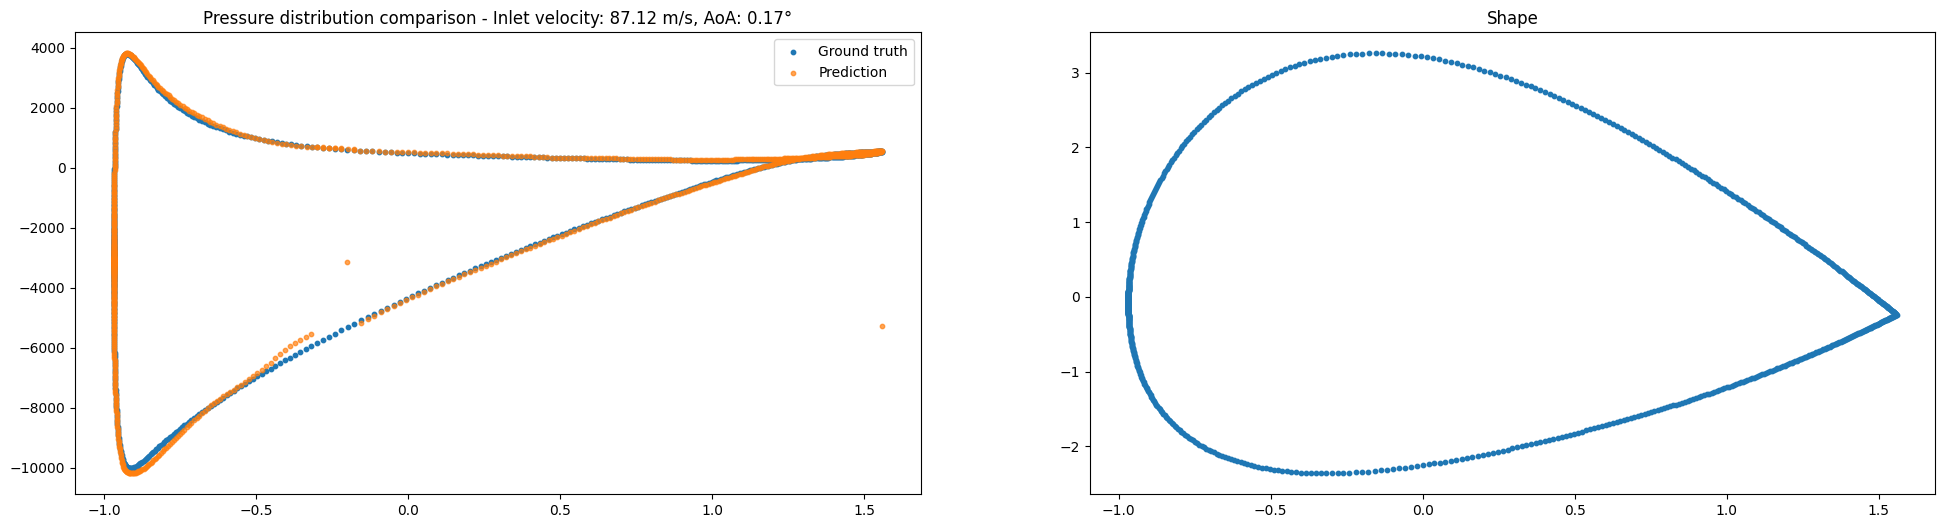

In [64]:
import matplotlib.pyplot as plt

idx = 14
mask_plot = masks_val[idx].numpy()
pressure_plot = pressure_val[idx][mask_plot].numpy()
coords_plot = coords_val[idx][:, mask_plot].numpy()
preds_plot = preds[idx][mask_plot].numpy()
conditions_plot = conditions_val[idx].numpy()
fig, ax = plt.subplots(1, 2, figsize = (24, 6))
ax[0].scatter(coords_plot[0], pressure_plot, label="Ground truth", s=10)
ax[0].scatter(coords_plot[0], preds_plot, label="Prediction", s=10, alpha=0.7)
ax[0].set_title(f"Pressure distribution comparison - Inlet velocity: {conditions_plot[0]:.2f} m/s, AoA: {conditions_plot[1]:.2f}°")
ax[0].legend()
ax[1].scatter(coords_plot[0], coords_plot[1], s=10)
ax[1].set_title("Shape")
plt.show()

In [18]:
from cetaceo.evaluators import RegressionEvaluator
# preds = preds * (cp_max - cp_min) + cp_min
evaluator = RegressionEvaluator()
metrics = evaluator(preds, pressures_val.squeeze())
evaluator.print_metrics()


Regression evaluator metrics:
mse: 0.0643
rmse: 0.2535
mae: 0.1654
mre: 0.5648%
ae_95: 0.5424
ae_99: 0.9180
r2: 1.0000
l2_error: 4.1803e-04


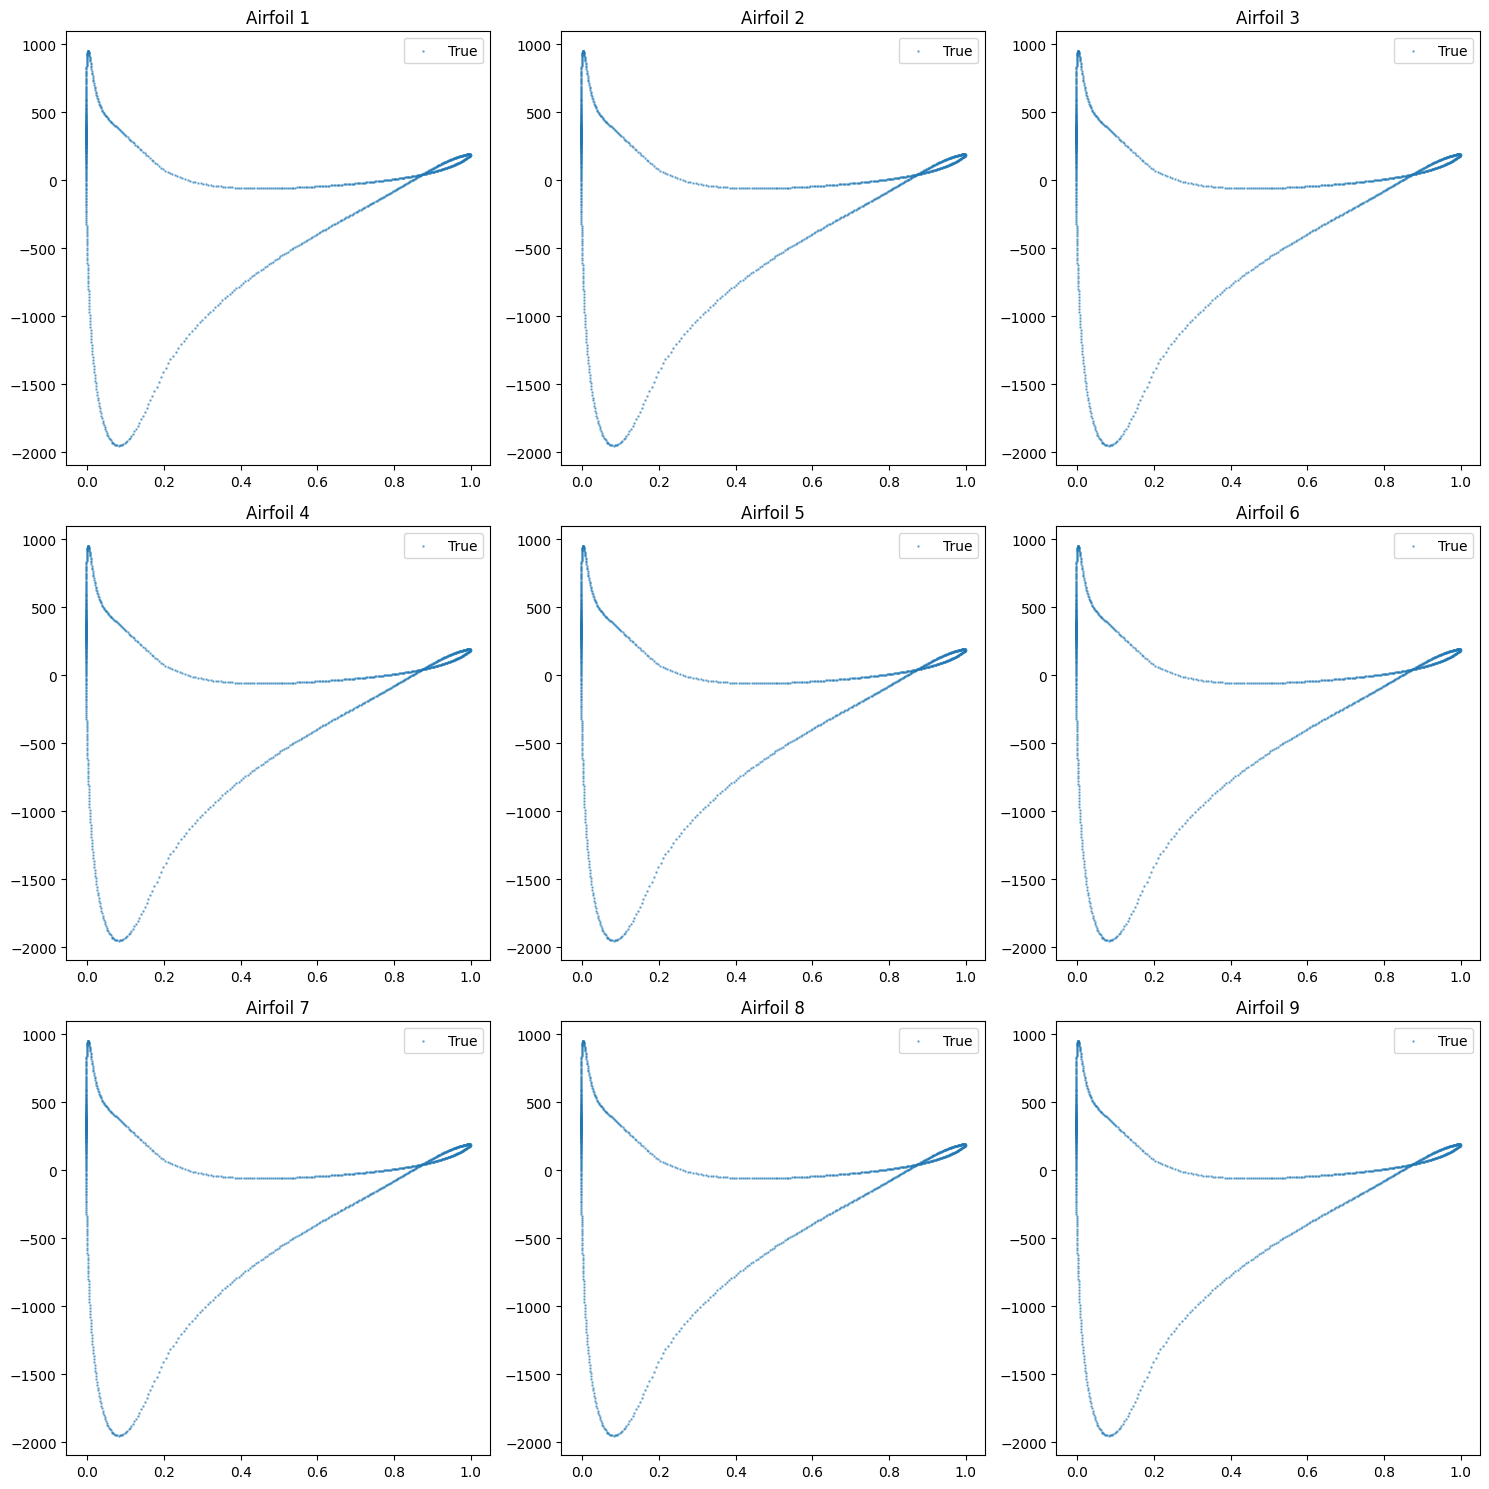

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 3, figsize=(15, 15))
for i, ax in enumerate(axs.flatten()):
    row = i // 3
    col = i % 3
    ax.scatter(data['coords'][i, 0], pressures[i].numpy(), label='True', alpha=0.5, s=0.75)
    # ax.scatter(coords[i], preds[i].numpy(), label='Predicted', alpha=0.5, s=0.75)
    ax.set_title(f'Airfoil {i+1}')
    ax.legend()
plt.tight_layout()
plt.show()
